Colab Link
https://colab.research.google.com/drive/1UV9bSq2FAJ7hYZ6NXZiCvWo5g8ELnK66

# Task-2: Generating Forecasts

**Lets tackle the Agenda 2 of our buisness case: Make future forecasts, with a MAPE score not more than 5%.**

We would need to see a few things before we can begin
- What is MAPE
- How to do train-test splits for time series


### Mean Absolute Percentage Error (MAPE)

To get the percentage error values we use **Mean Absolute Percentage Error** (MAPE), which is obtained by dividing the absolute error with actual value and finding the mean of these terms.

Formula:


<center><h3> $MAPE = \frac{1}{N} \sum_{i=1}^{N}\left | \frac{y_{i}-\hat{y}_{i}}{y_i} \right |$</h3></center>



> **Q. What is advantage of of using MAPE  as business case metric?**

As opposed to other metrics used for time series (ME, MAE, MSE, RMSE), MAPE doesn't provide relative comparison of models. It is an absolute comparison.

With MAPE, we get an percentage of correct forecasts. We don't need to to look at MAPE values of other models to get an idea of how our model is performing in comparison.

<br>

> **Q. What if y = 0 for a point?**

That would be a problem as MAPE would become **undefined** for the entire data that way.

Therefore, one would have to use another metric for the points where real value is 0. This is just inconvenient.


---

### Train Test Splits

Now that we've performed all the data preprocessing, let's split our data into training and testing sets.

<br>

By now, we're familiar with the `train_test_split()` method.

But unfortunately, we cannot use it here, for time series.

<br>

> **Q. Why can't we use `train_test_split()` for time series?**

Recall that a time series is a collection of data over time.

In time series forecasting, we're essentially looking at the past data to predict future values.

So, naturally, we can **NEVER do a random shuffle** for train and test data split. That would be meaningless.

And, as we are aware, `train_test_split()` shuffles the data while splitting.

<br>

**Note:**
- We can however, perform a K-fold.

<br>

> **Q. What's the right way?**

In case of time series, we need to do a **time based splitting**, and not a random shuffle split.

Look at the figure below, we split data based on time into train, validation and test sets.

  <center><img src="https://drive.google.com/uc?id=1ytwtHI1DeKiHAkaILgrbnzlkbfLDOAg-" width="800" height="500"> </center>

<br>

> **Q. How can we obtain these splits?**

Consider the use case we're working on.

Out of the 18 years of data, we decide to train on 17 years of data, and use the last year, i.e. the last 12 values for test data.

We can simply use **slicing** to obtain these sets.


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


In [ ]:
plt.rcParams['figure.figsize'] = (20,6)

downloading our csv file

In [ ]:
!gdown 1q8KKl03WBxrhcwCZcLDrlavVYyUfUdlf

Downloading...
From: https://drive.google.com/uc?id=1q8KKl03WBxrhcwCZcLDrlavVYyUfUdlf
To: /content/myntrasales.xlsx
100% 13.7k/13.7k [00:00<00:00, 35.1MB/s]


In [ ]:
myntra_sales = pd.read_excel('/content/myntrasales.xlsx')
myntra_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [ ]:
# set index as date
myntra_sales.set_index('DATE', inplace=True)

myntra_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


## Data Preprocessing

Let's do all the data processing we learnt about in the last lecture
- Setting index as date
- Perform linear interpolation
- Taking care of anomalies by clipping values using quantiles
- Plotting the resultant time series

<Axes: xlabel='DATE'>

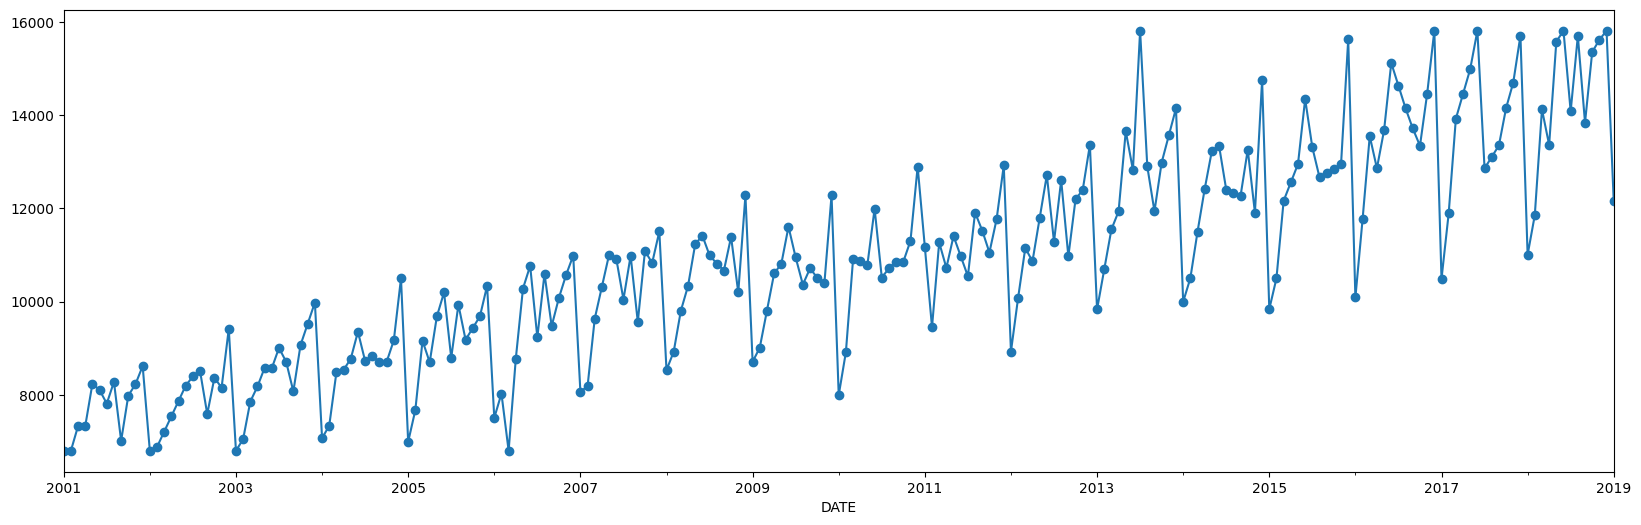

In [ ]:

# linear interpolation
myntra_sales.Sales = myntra_sales.Sales.interpolate(method='linear')

# anomalies - clip quantiles
myntra_sales.Sales = myntra_sales.Sales.clip(upper=myntra_sales.Sales.quantile(0.98), lower=myntra_sales.Sales.quantile(0.02))

# plot
myntra_sales.Sales.plot(style='-o', figsize=(20,6))

In [ ]:
train_max_date = myntra_sales.index[-12]
train_x = myntra_sales.loc[myntra_sales.index < myntra_sales.index[-12]].copy()
test_x = myntra_sales.loc[myntra_sales.index >= myntra_sales.index[-12]].copy()

test_x

,Sales
DATE,
2018-02-01,11852.0
2018-03-01,14123.0
2018-04-01,13360.0
2018-05-01,15576.0
2018-06-01,15809.4
2018-07-01,14080.0
2018-08-01,15697.0
2018-09-01,13838.0
2018-10-01,15351.0


> **Q. Where is the `train_y` and `test_y`?**

Recall that in our dataset, we have only one column of data i.e. the sales column.

Besides sales, there is no other data.

We only have dates (time) that we're using as index.

So, we cannot create a y column, if there are no columns.

Also, let's create a function  to estimate the performance of different models

In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

## Simple Forecast Methods

Lets take a look at a few fundamental (not-so-intelligent) approaches

Consider that we are given a time series, and it looks like:-

  <center><img src="https://drive.google.com/uc?id=1CGMclmPGH0WCqbWU-CN4JkH069dw2JEx" width="600" height="400"> </center>


We are supposed to forecast the value for this series at time t=k





### 1. Forecasting the mean



> **Q. What if we forecast the mean of the time series as the value at t=k?**

Intuitively, this may make sense.

This would be the easiest forecast possible.

$Mean = \frac{x_1 + x_2 + ... + x_{k-1}}{k-1}$

Lets see what that would look like.


  <center><img src="https://drive.google.com/uc?id=1U2FRD1SN_Vv6Kca3d0x1MWZtKaSuEaoU" width="600" height="400"> </center>



<br>

> **Q. As per this rule, what would be the forecast for t=k+1?**

Realistically, k would be a large value, as our time series would contain considerable amount of data for us to forecast a new value.

Say, k = 1,00,000

Using the same rule, we now take the mean for data upto t=k.

$New \ Mean = \frac{x_1 + x_2 + ... + x_{k-1} + x_k}{k}$

Regardless of the value of data point $x_k$, the New Mean would be approximately equal to the old mean we calculated.

<br>

So, if we stick to this rule, then on plotting, we would actually end up having a straight line of forecast


  <center><img src="https://drive.google.com/uc?id=1ZCKMDf7n7IkYVxFDl6NncRhg20o4j3Bo" width="600" height="400"> </center>


This doesn't seem very useful.


<br>

**NOTE:** A similar argument can be made for **median**. So, we can rule out using median of entire data as future forecast values.

In [ ]:
train_x['Sales'].mean()

10653.201951219511

MAE : 3786.031
RMSE : 4025.906
MAPE: 0.255


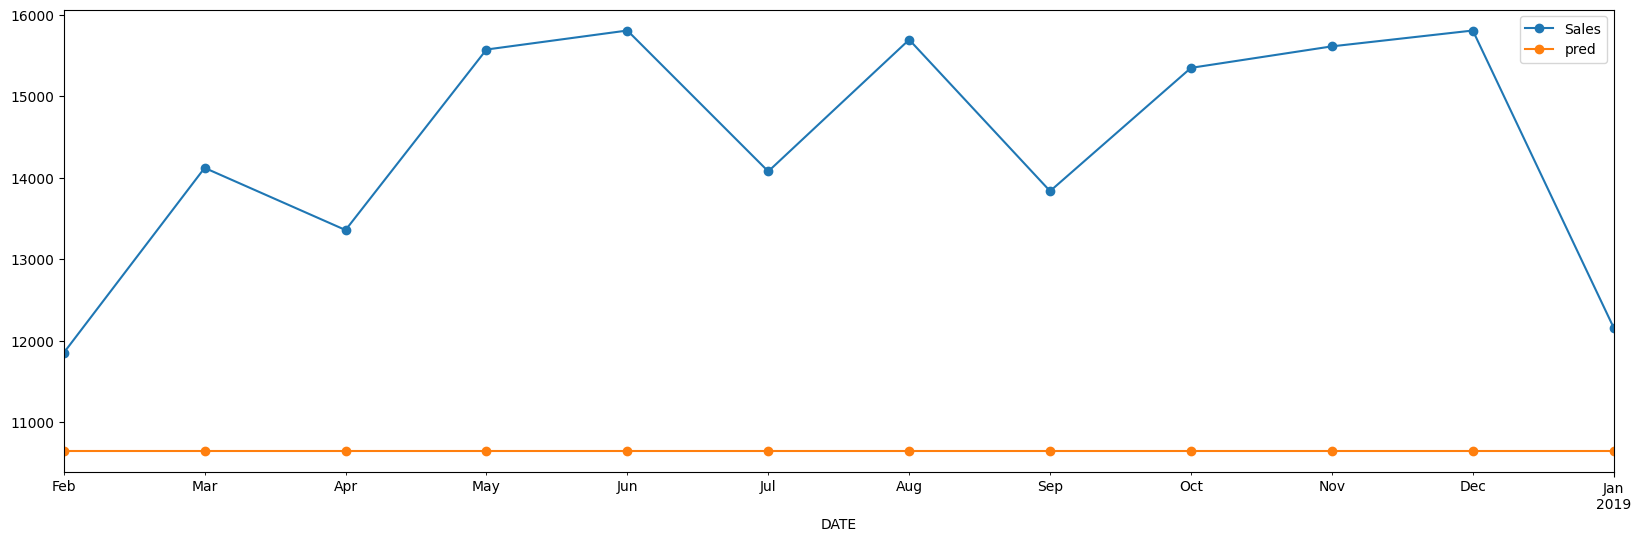

In [ ]:
test_x['pred'] = train_x['Sales'].mean()

test_x.plot(style='-o')

performance(test_x['Sales'], test_x['pred'])

It is evident that this a very bad model.

> **Q. How do we interpret the MAE score?**

This is mostly used in cases where we need to **compare multiple models.**

In such a case, we can say how well each model is performing, based on which model fetches the lowest MAE.

In this case, we can interpret it as, given that the model's values fluctuate between roughly 6k to 16k, and within those fluctuations, this model's error is around 3.7k approx.

The mean of data is approx 10k, and we're getting an MAE of 3.7k, this means roughly 37% predictions are wrong, **with respect to the mean**.

This is not good.

<br>

> **Q. How do we interpret the RMSE score?**

This value also, we're getting around 4k, which is close to the MAE

This metric is also used to **compare** performance among different models.

This value also doesn't seem to be good.

<br>

> **Q. How do we interpret the MAPE score?**

This is straightforward to intrpret.

For this model, we get MAPE as 0.255. This means that we have 25.5% error, **with respect to its own value**.

Lets look at some other way to forecast future values
### 2. Naive Approach



> **Q.What if we take the current value, and forecast that?**

Let's simply take the value of series at time $t=k-1$ (i.e. $x_{k-1}$), and forecast that for all future.

This is called the **Naive** approach of forecasting.

  <center><img src="https://drive.google.com/uc?id=1yhuUok4-WMOQzJ244inmkjSh1shkmrL8" width="600" height="400"> </center>


> **Q. What if we get a different value for series at t=k, would this not change all the future forecasts we had made earlier?**

Yes, as per this rule, it would.

This raises a conflict.

For example,
- Based on data available till March, you forecast that June sales would be $X_{March}$
- But after the month of April, you tell the client that, now the June sales should be $X_{April}$
- Not to mention, your forecast for April came out to be incorrect as well.
- You can easily loose the client's trust based on this approach

Hence, this is not a very intelligent approach.



In [ ]:
train_x['Sales'][-1]

11005.0

MAE : 3434.233
RMSE : 3697.005
MAPE: 0.23


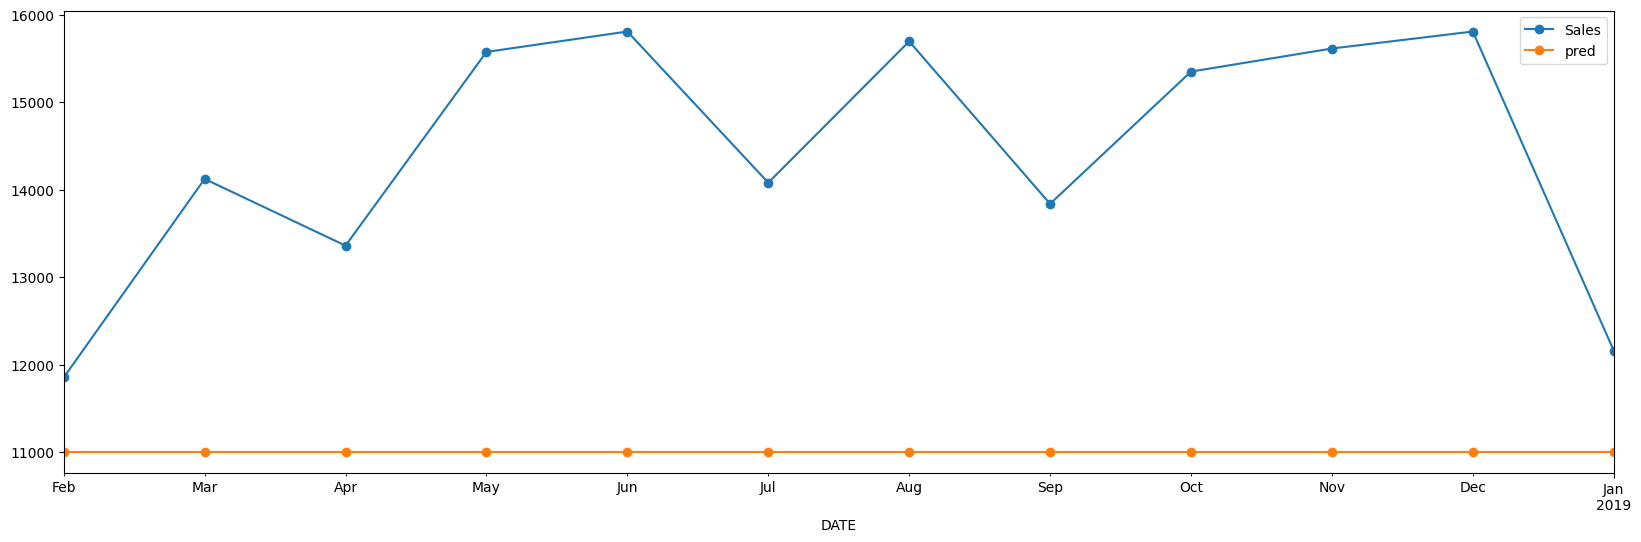

In [ ]:
test_x['pred'] = train_x['Sales'][-1]

test_x.plot(style='-o')

performance(test_x['Sales'], test_x['pred'])

This model's performance is slighly better, but we can see it's still really bad.

###### **Quiz-5:**

```
Forecasts are said “Naive” when:

a. They are based only on the past values of the variable
b. They are short-term
c. They are long-term
d. They predict incorrect forecasts


```
Answer: a - They are based only on the past values of the variable

---

### 3. Seasonal Naive Forecast

We can perhaps take a smarter approach to optimise the Naive method.

> **Q. What if we consider the seasonality patterns?**

We can set each forecast to be equal to the last observed value from the same season (e.g., the same month of the previous year).

This way, we're essentially forecasting the future values to be exactly same as last season.

This is called **Seasonal Naive Forecast**.

  <center><img src="https://drive.google.com/uc?id=1JLP65ufaO_uFfUxctbVi7wh8V7qxBwcO" width="700" height="500"> </center>


MAE : 800.867
RMSE : 1067.837
MAPE: 0.055


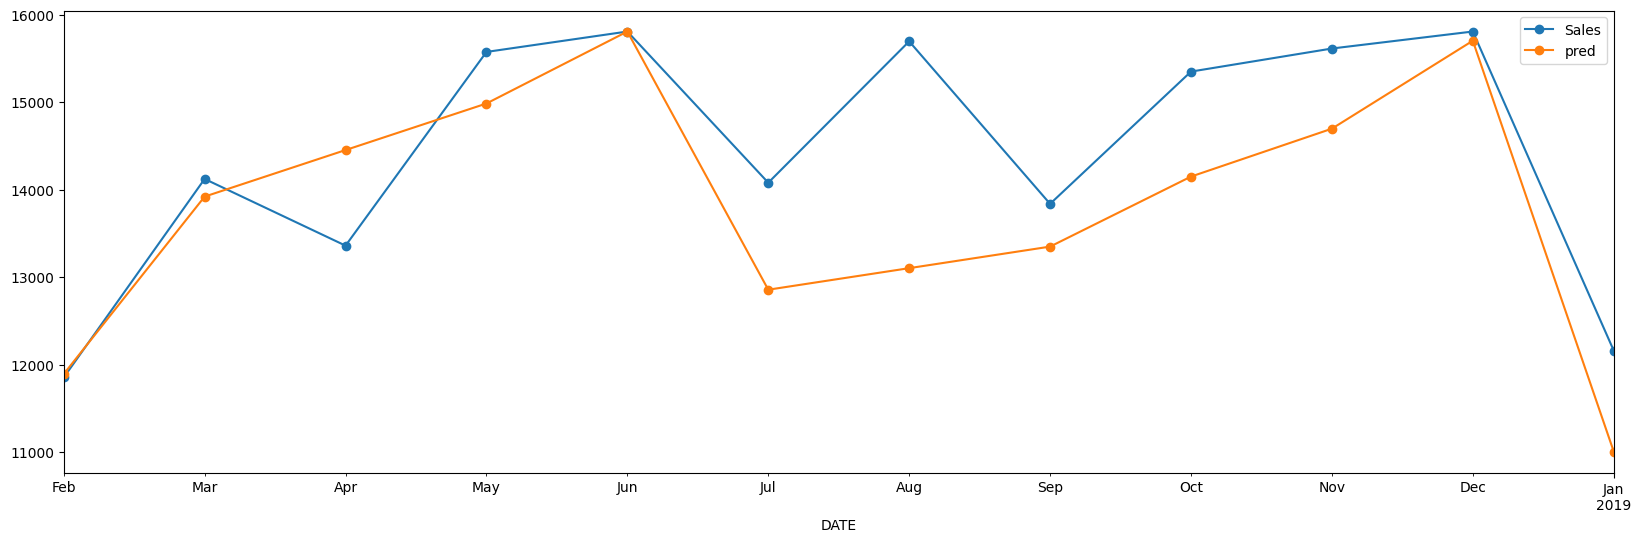

In [ ]:
for i in test_x.index:
  test_x.loc[i]['pred'] = train_x.loc[i - pd.DateOffset(years=1)]['Sales']

test_x.plot(style='-o')

performance(test_x['Sales'], test_x['pred'])

These simple models are not exactly giving any smart forecasts.

#### Q. Why are we studying simple methods?
Sometimes one of these simple methods will be the best forecasting method available.

But in many cases, these methods will serve as benchmarks rather than the method of choice.

That is, any forecasting methods we develop will be compared to these simple methods to ensure that the new method is better than these simple alternatives.

If not, the new method is not worth considering.

###### **Quiz-6:**

```
Statement I: Naive method is capable of capturing seasonality.

Statement II: Forecasting with mean/median value will give a flat forecast around mean/median value

Statement III: Seasonal Naive is capable of capturing seasonality as well as trend.

Which of the above statements is/are true?

a. Statement I
b. Statement II
c. Statement III
d. All of them are true

```
Answer: b - Statement II  

## Moving average forecasting

we have already seen how we impute values with moving averages now we want to do a forecast based on that

### How can we do a forecast with moving average

In [ ]:
import numpy as np

df = myntra_sales.copy()

In [ ]:
#
pd.DataFrame(index = pd.date_range(start=df.index[-1], periods=12, freq='MS'))

""
2019-01-01
2019-02-01
2019-03-01
2019-04-01
2019-05-01
2019-06-01
2019-07-01
2019-08-01
2019-09-01
2019-10-01


pd.date_range: This is a function call to create a range of dates in pandas.

- start: This specifies the start date of the date range.

- periods: This specifies the number of periods (in this case, months) to generate. It's set to 12, so it generates a date range for 12 months.

- freq: This specifies the frequency of the date range. It's set to 'MS', which means it generates dates with month start frequency.

Putting it all together, this line of code creates a new pandas DataFrame with an index consisting of 12 dates starting from the last date in the index of DataFrame df, with each date representing the start of a month.


- we got the first entry as Jan-2019, which already existed in our series.
- In order to take care of this, we need to explicitly mention that we want values from the second index of the result of `pd.date_range()`
- Hence we utilise slicing by mentioning `[1:]`

In [ ]:
df = df.append(pd.DataFrame(index = pd.date_range(start=df.index[-1], periods=13, freq='MS')[1:]))
df.tail(20)

,Sales
2018-06-01,15809.4
2018-07-01,14080.0
2018-08-01,15697.0
2018-09-01,13838.0
2018-10-01,15351.0
2018-11-01,15615.0
2018-12-01,15809.4
2019-01-01,12160.0
2019-02-01,NaN
2019-03-01,NaN


In [ ]:
pred = df.Sales.dropna().values

for i in range(12):
  pred = np.append(pred, pred[-3:].mean())

pred[-20:]

array([15809.4       , 14080.        , 15697.        , 13838.        ,
       15351.        , 15615.        , 15809.4       , 12160.        ,
       14528.13333333, 14165.84444444, 13617.99259259, 14103.99012346,
       13962.6090535 , 13894.86392318, 13987.15436671, 13948.20911446,
       13943.40913479, 13959.59087199, 13950.40304041, 13951.13434906])

So, we can see that we have forecasts here, based on average of last 3 points for all new points.


Now let's plot this.

<Axes: >

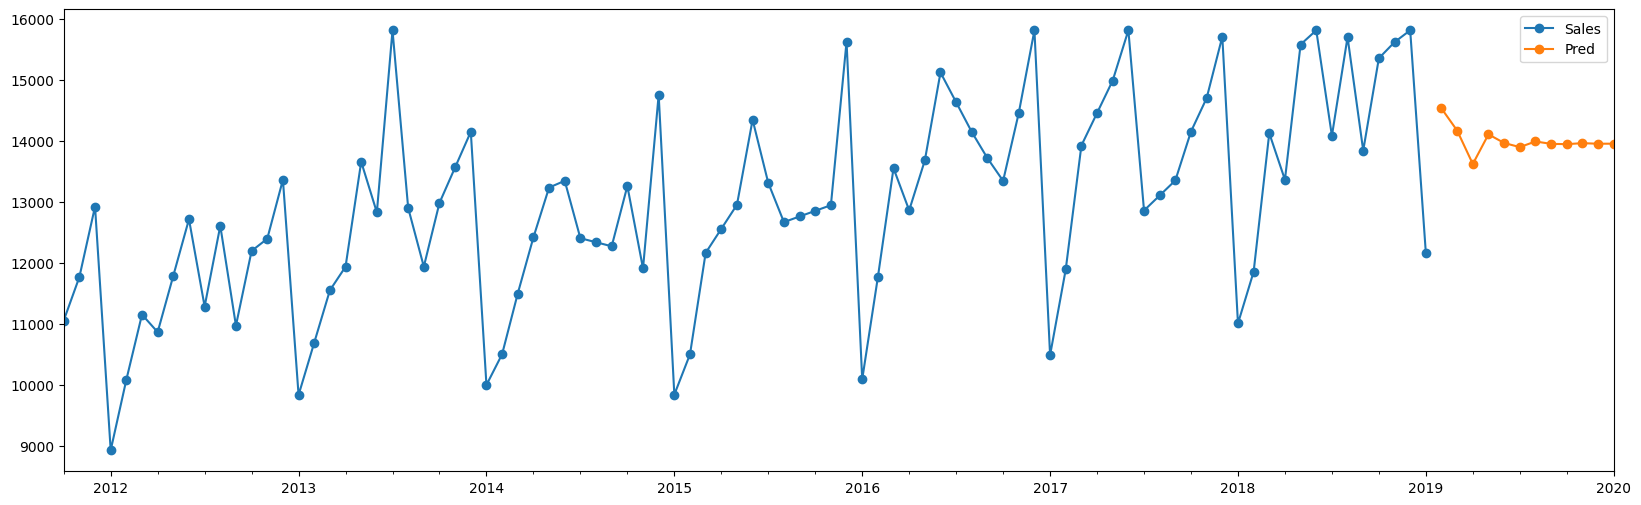

In [ ]:
df['Pred'] = pred

df.loc[~df['Sales'].isna(), 'Pred'] = np.nan
df.tail(100).plot(style='-o')

> **Q. Does this look like a good forecast?**

These forecasted values are certainly better than forecasting the mean/median or any constant values. At least, the levels looks okay.

However, it can be clearly seen that the forecast is not able to predict the variations and it gives a flat line after few predictions.

<br>

Also, if you think about it, this technique, doesn't seem to using the past data.

What is the point of having data spanning over 18 years, if we're just looking at the last 3 entries to forecast a new value.

> **Q. What would be the performance of the Moving Averages model?**

While we're at it, let's check the performance of Moving Averages model also, by using train and test sets.

MAE : 1692.467
RMSE : 1875.03
MAPE: 0.115


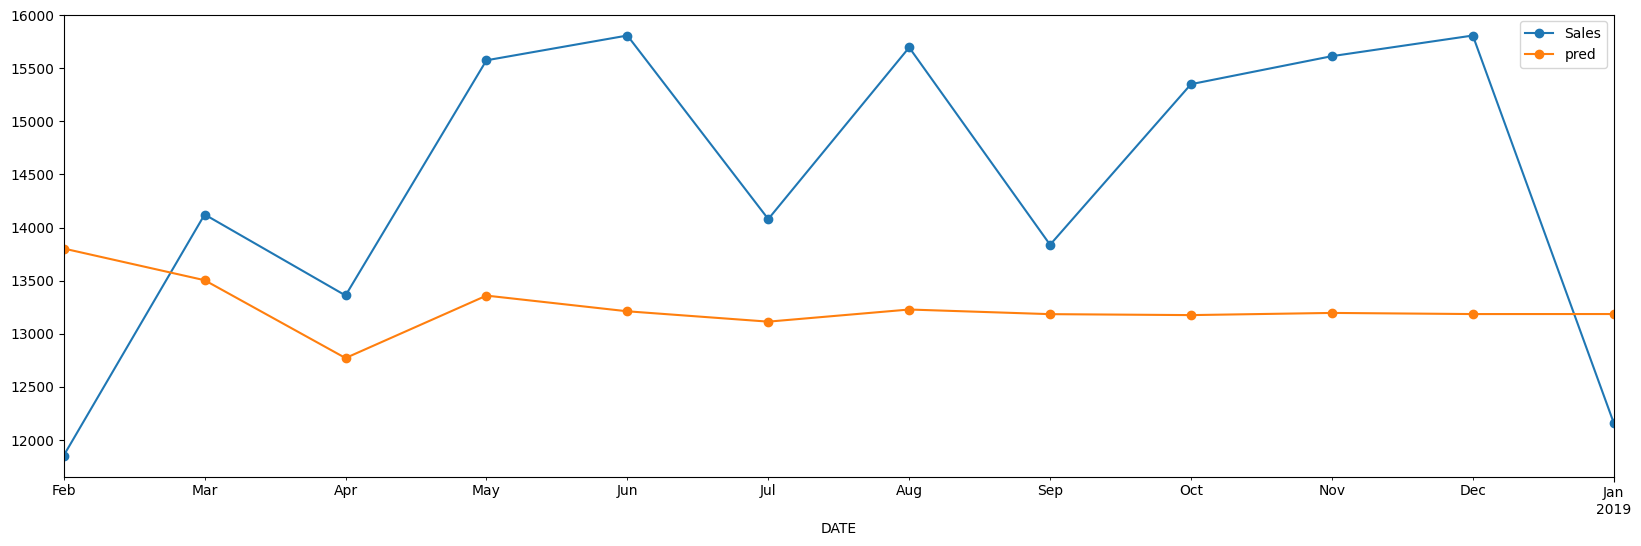

In [ ]:
df = train_x.copy()

df = df.append(pd.DataFrame(index = pd.date_range(start=df.index[-1], periods=12, freq='MS')[1:]))

pred = df.Sales.dropna().values

for i in range(12):
  pred = np.append(pred, pred[-3:].mean())

test_x['pred'] = pred[-12:]
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### Drawbacks

- we see that after a few forecast points it seems to level out
- because it takes in consideration the last three point only the varince or spread decreases everytime till we get a straight line

# Simple exponential smoothing

As we saw just taking in account the recent values only is not the best solution, so what we want is to take in consideration the rest of the series as well

we will assign small weights to the past values instead of ignoring them completely.

Exponential Smoothing uses a weighted moving average as the forecast, with the assigned weights decreasing exponentially for periods farther in the past.

> Forecasts produced using exponential smoothing methods are weighted averages of past observations, with the weights decaying exponentially as the observations get older. In other words, the more recent the observation the higher the associated weight.

- SES forecast for next time step can be interpreted as a combination of previous time step's actual value and the forecast of the previous time step

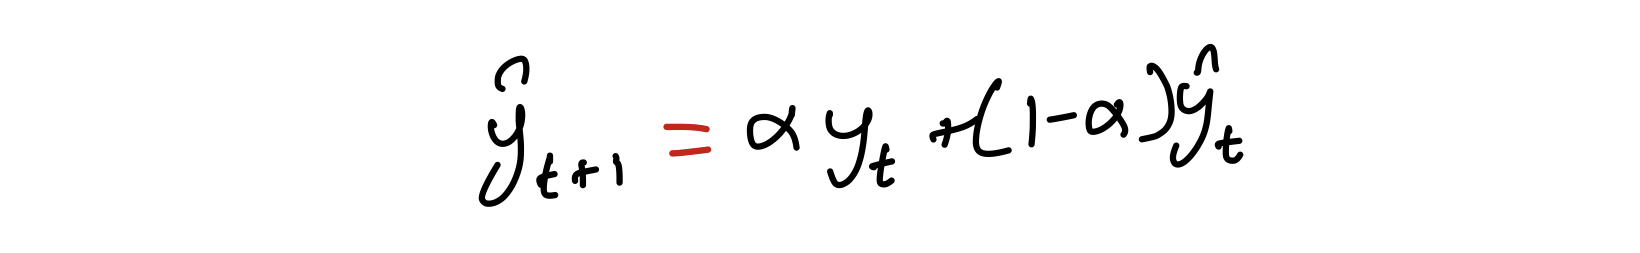

It requires a single parameter, called alpha (a), also called the smoothing factor or smoothing coefficient.

This parameter controls the rate at which the influence of the observations at prior time steps decay exponentially.

- Alpha values can range from 0 to 1, inclusive. Lower values produce smoother fitted lines because they give more weight to past observations, averaging out fluctuations over time. Higher values create a more jagged line because they weigh current data more highly, which reduces the degree of averaging by the older data.

> A weight of 1 causes the most recent observation to have all the weight, while all previous observations have no impact on the model. Consequently, the forecast values for α = 1 are simply the current value, which analysts refer to as naïve forecasting.

 ## $ \hat{y}_{t+1} = ay_t + (1-a)\hat{y}_{t-1}$
 ### Y pred at t+1 is equal to alpha times observed y at t  plus 1 minus alpha times y predicted at t

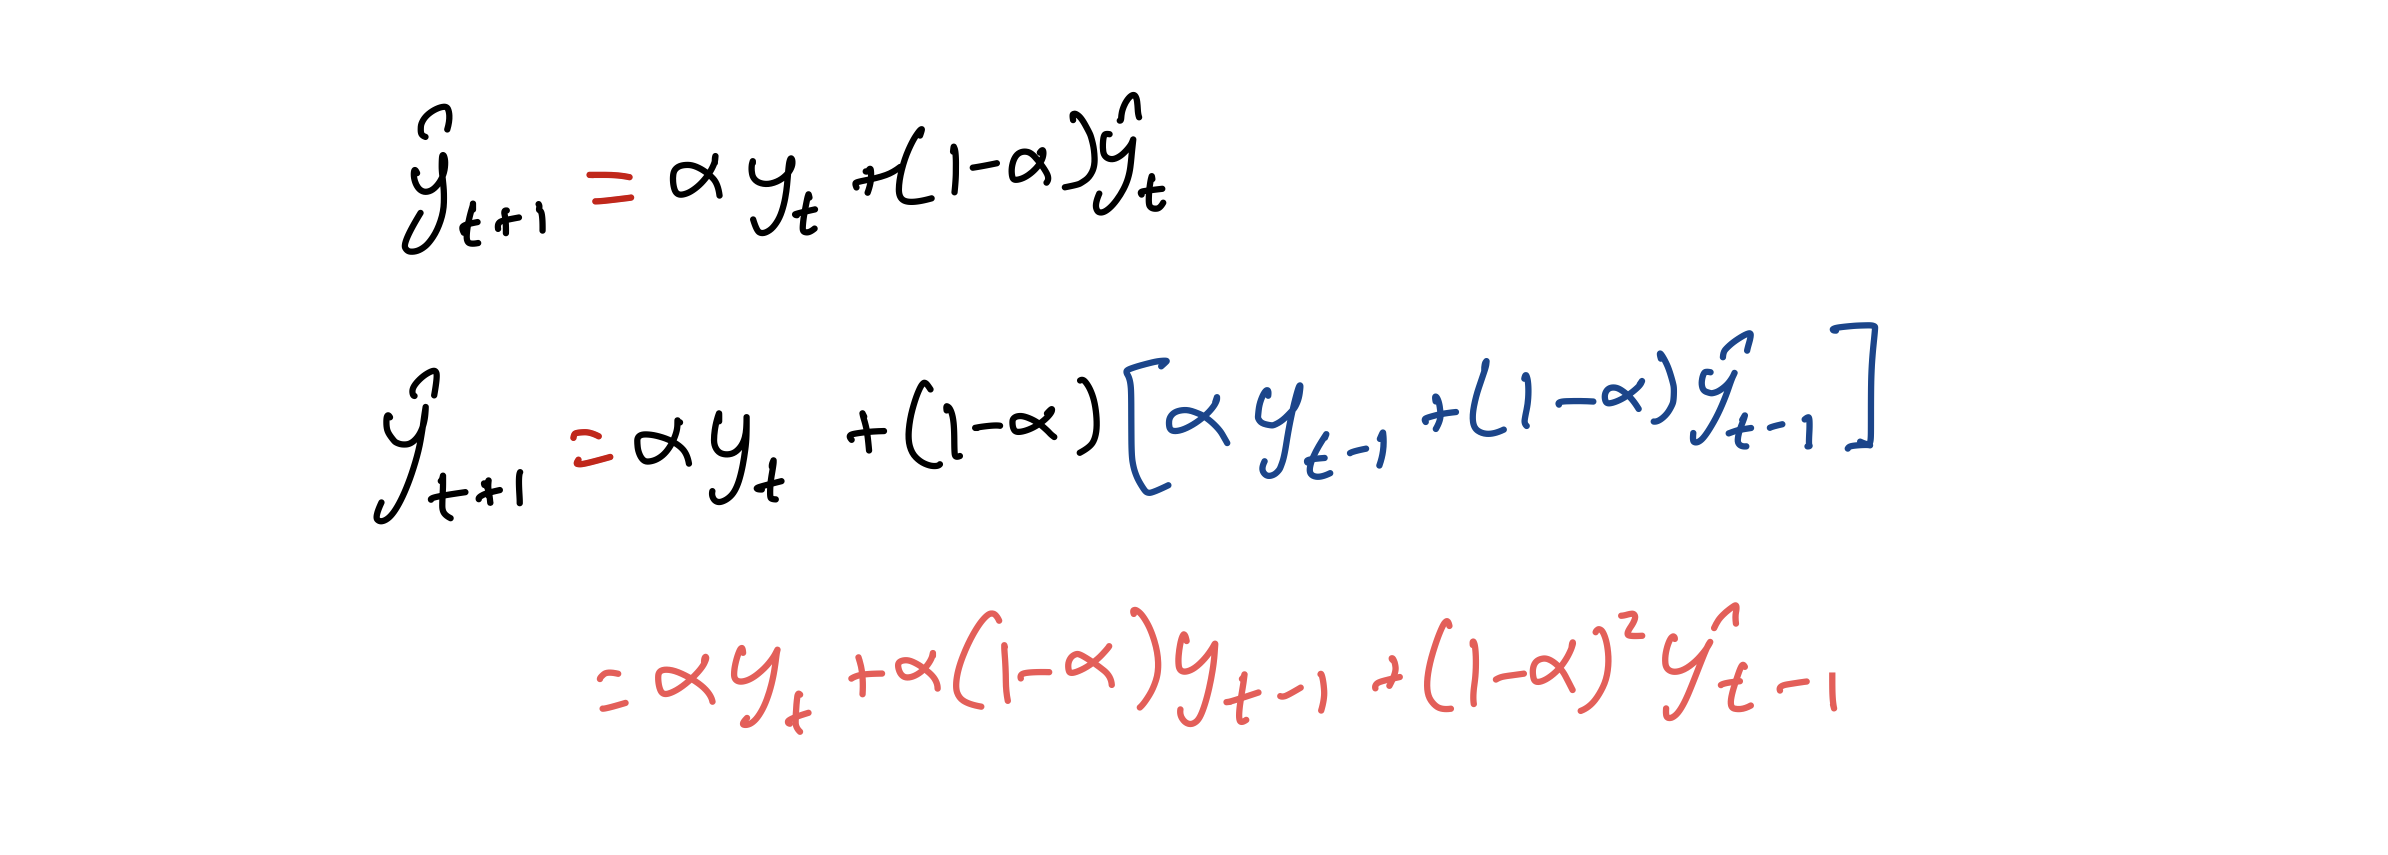

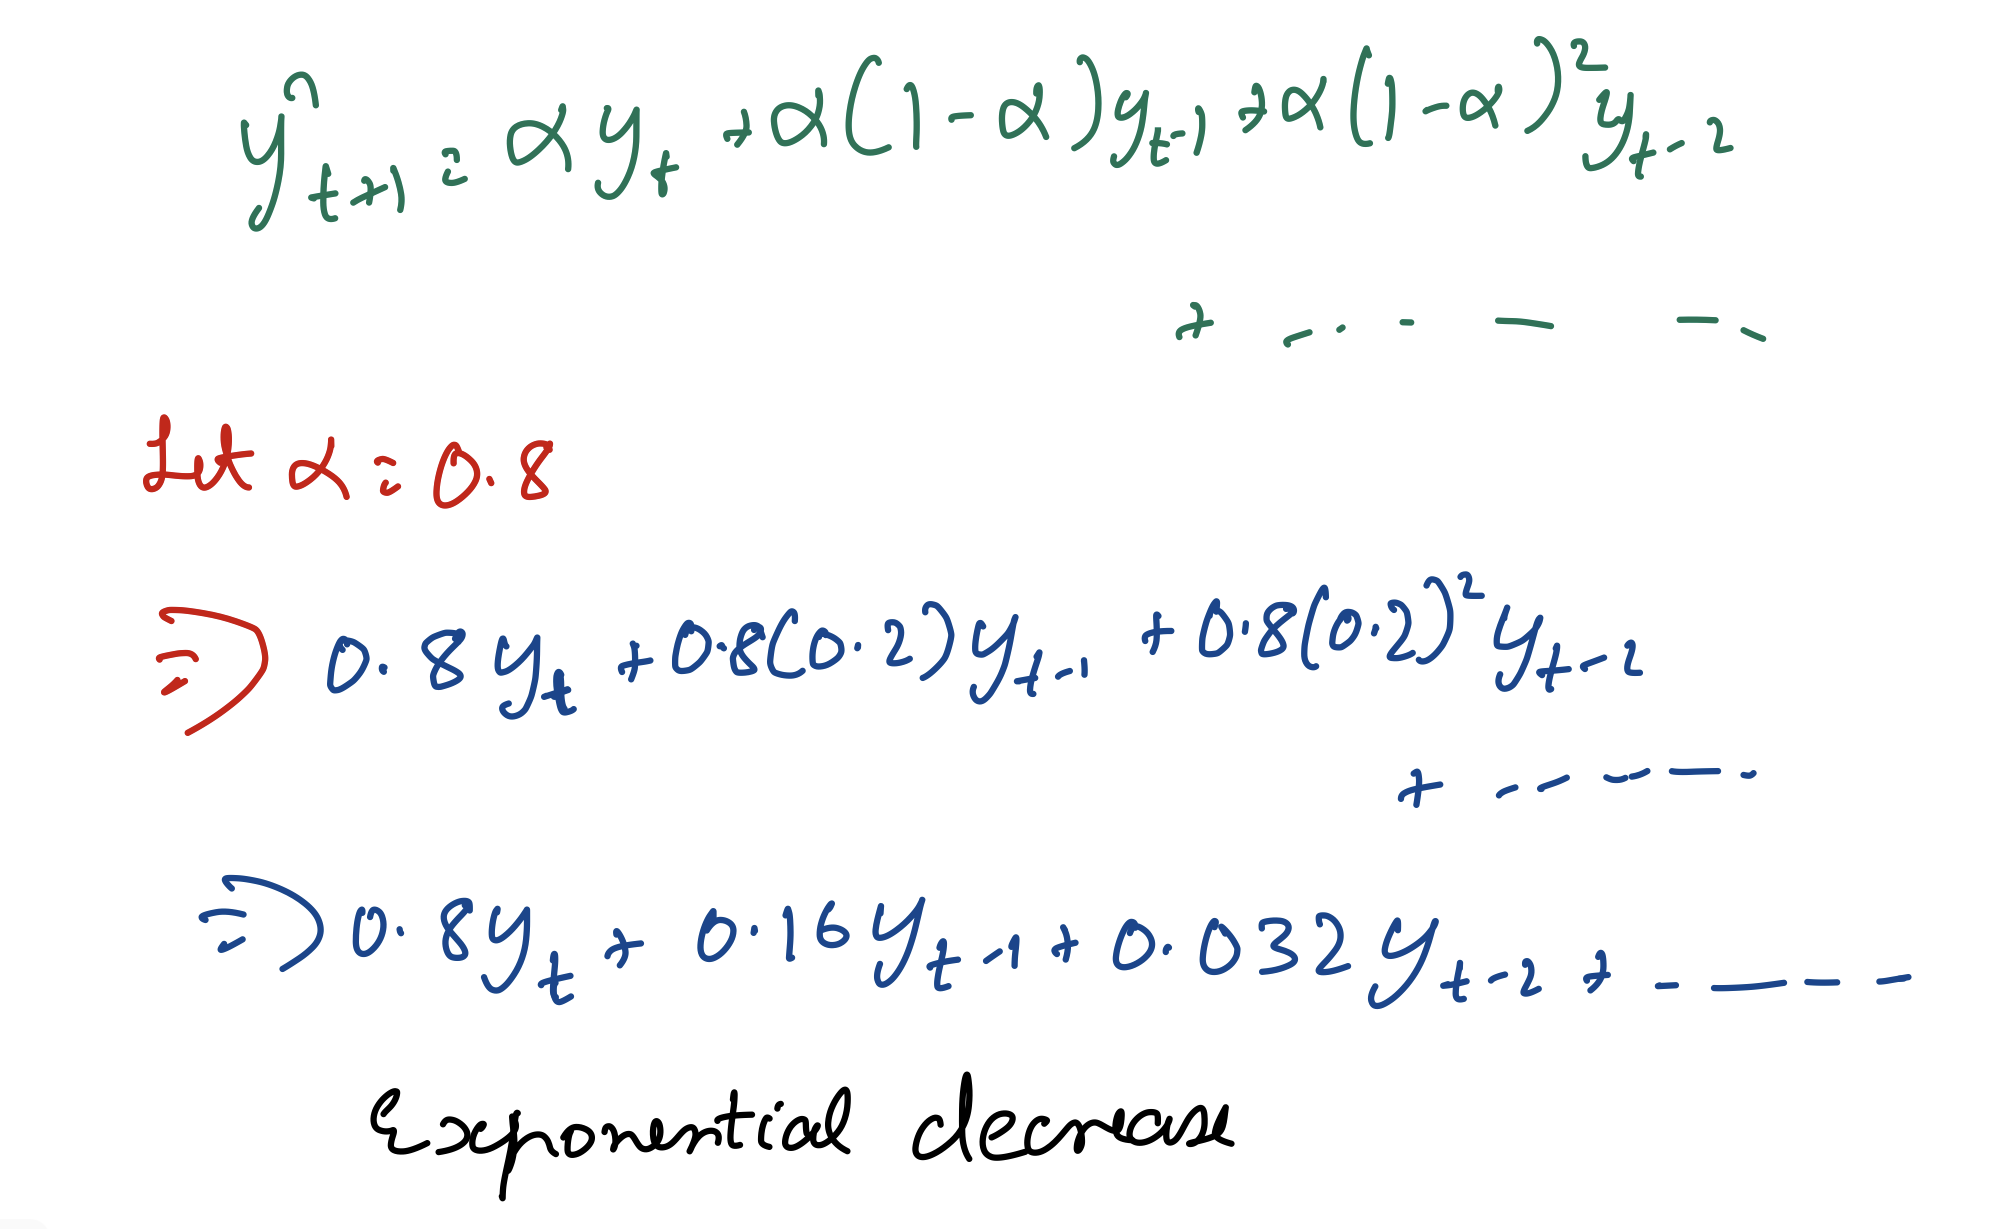

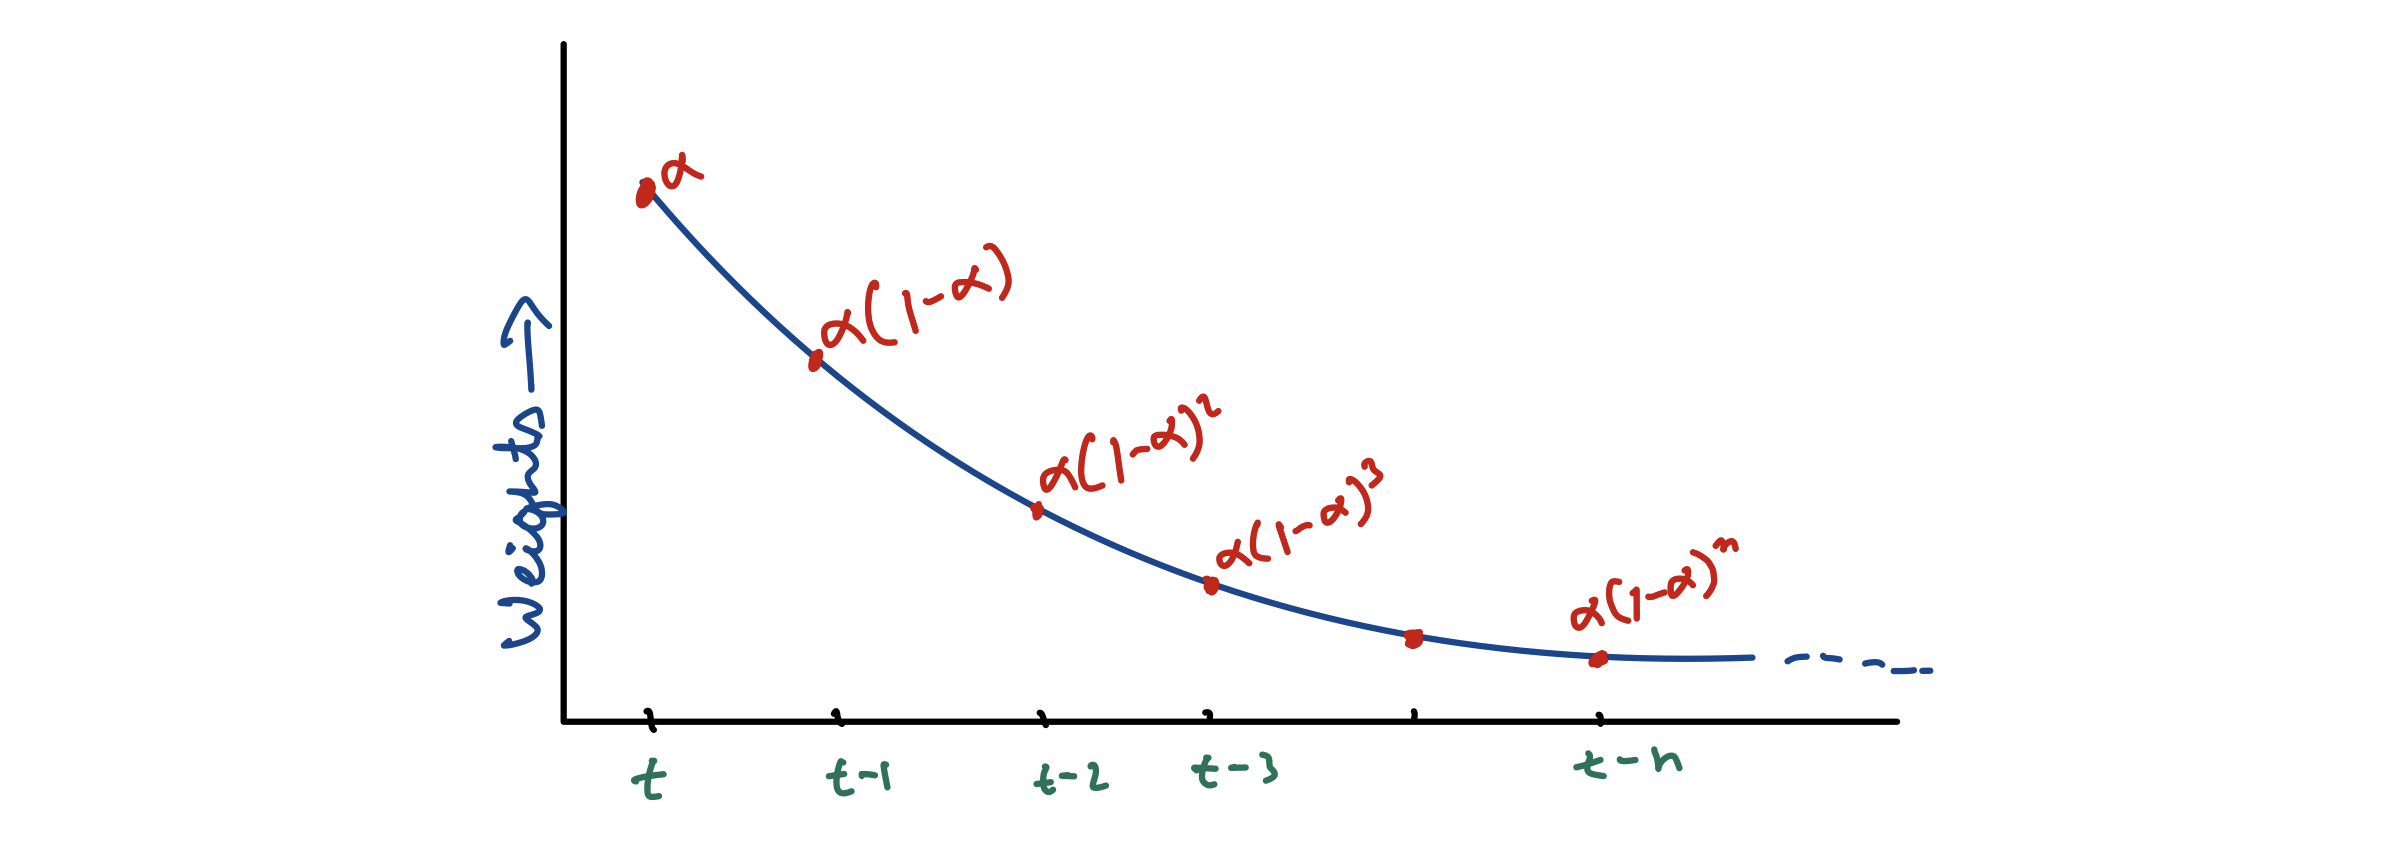

There is a necessary trade-off to be made here between learning and remembering, between being reactive and being stable. If alpha is high, the model will allocate more importance to the most recent demand observation (i.e., the model will learn fast), and it will be reactive to a change in the demand level. But it will also be sensitive to outliers and noise. On the other hand, if alpha is low, the model won’t notice a change in level rapidly, but will also not overreact to noise and outliers.

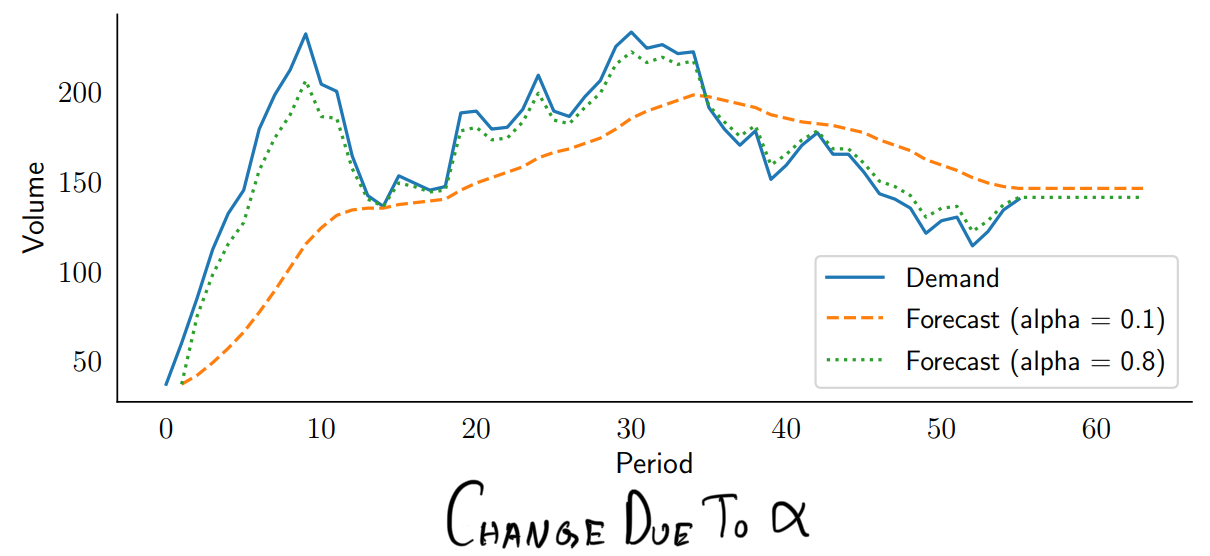

### Code implimentaion using statsmodel
Let's look into the code for the same.

We have a built-in method for this technique `SimpleExpSmoothing()`, under **statsmodels** library.

While fitting this model, we need to specify the `smoothing_level` parameter, which is the same as $\alpha$ we've been looking at.

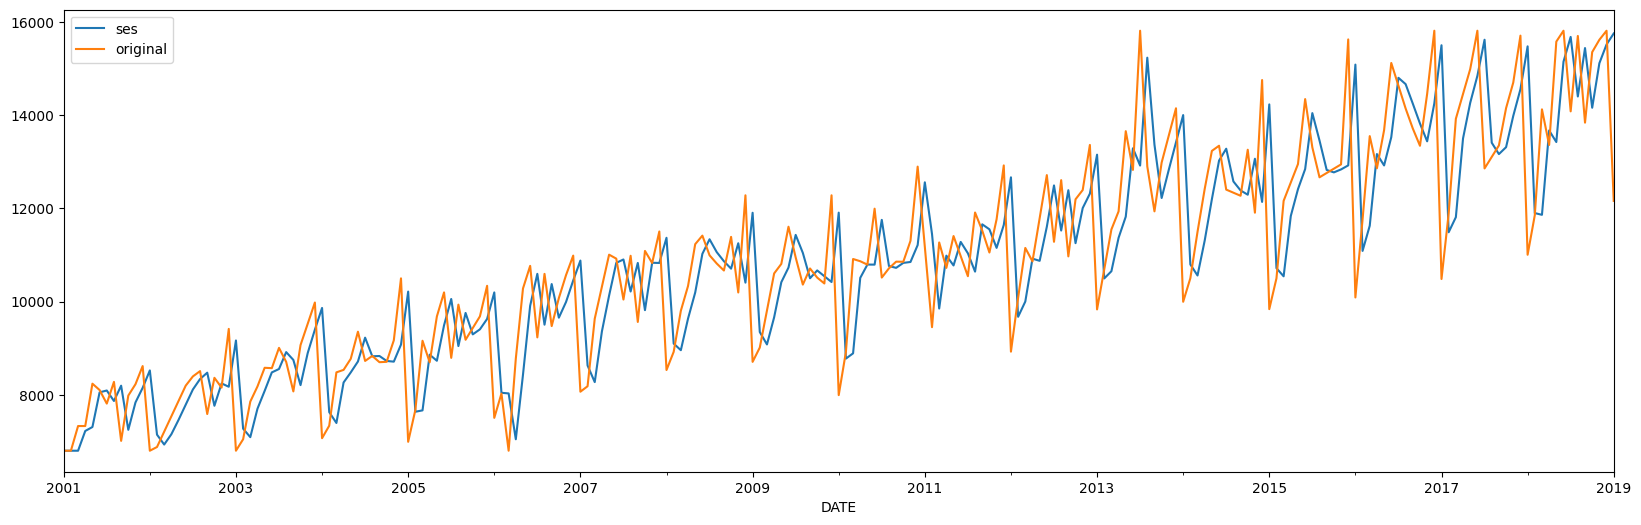

In [ ]:
model = pd.Series(sm.tsa.SimpleExpSmoothing(myntra_sales.Sales).fit(smoothing_level=0.8).fittedvalues)

model.plot(label='ses')
myntra_sales.Sales.plot(label='original')
plt.legend()


- The recommended starting point value for `smoothing_level` is $\frac{1}{2* seasonality}$
- For our case, this becomes $\frac{1}{2*12}$


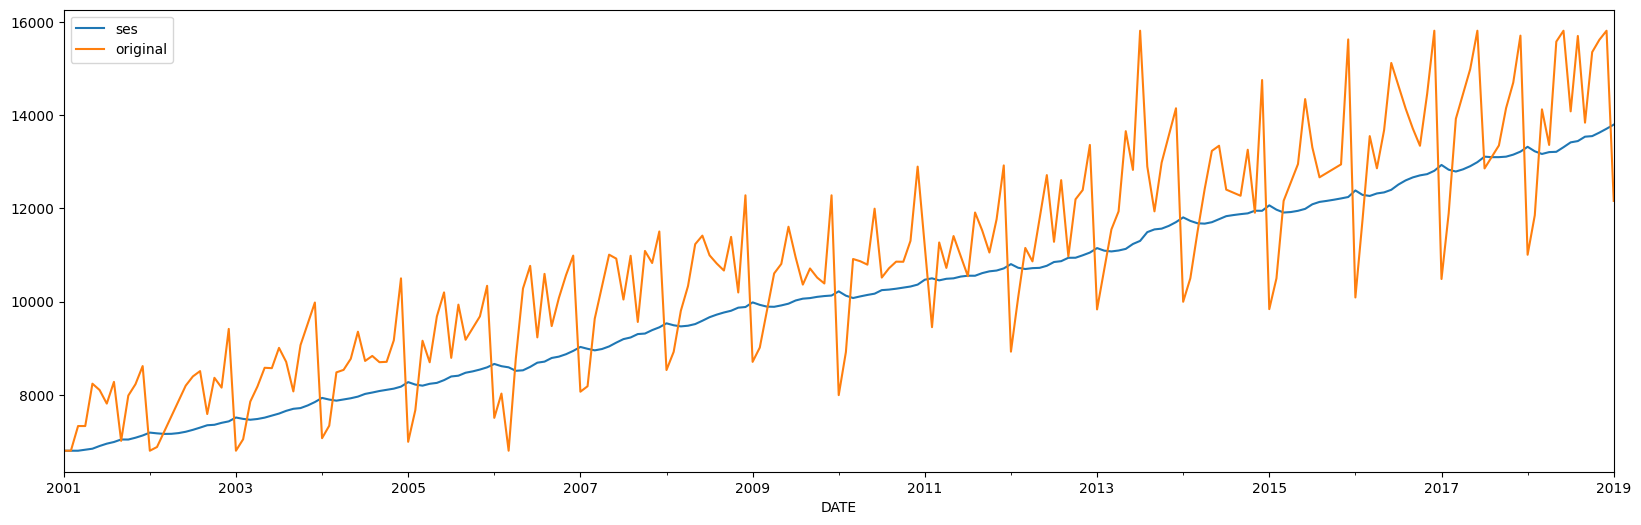

In [ ]:
model = pd.Series(sm.tsa.SimpleExpSmoothing(myntra_sales.Sales).fit(smoothing_level=1/(2*12)).fittedvalues)

model.plot(label='ses')
myntra_sales.Sales.plot(label='original')
plt.legend()

From the graph, it looks like the Simple Exponential Smoothing, got the levels right.

> **Q. How is this plot different from Moving Averages plot?**

This looks similar.

But, Unlike moving averages, it **does not have the offset** in beginning and end, because this method is initialised properly.

They fix the previous values as well.

<br>

> **Q. How can we make future forecasts from this method?**

`SimpleExpSmoothing` in statsmodels also have a `forecast()` method.

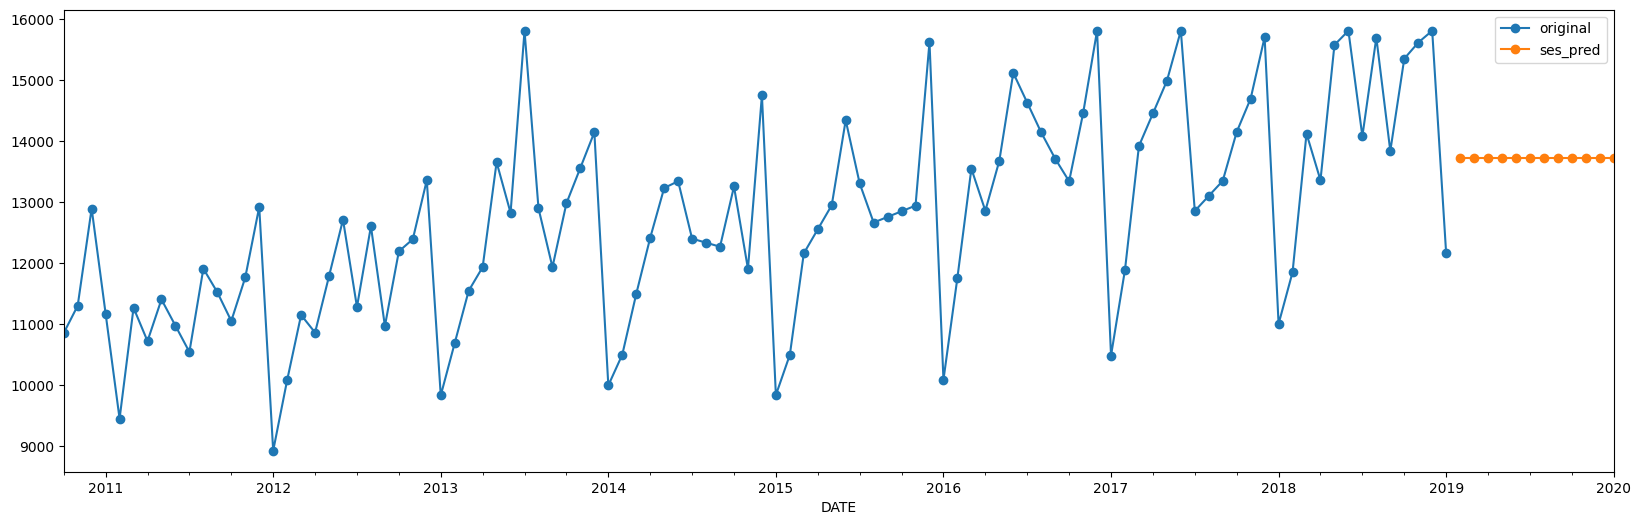

In [ ]:
model = sm.tsa.SimpleExpSmoothing(myntra_sales.Sales).fit(smoothing_level=1/(2*12))
pred = model.forecast(steps = 12)

myntra_sales.Sales.tail(100).plot(label='original', style='-o')

pred.plot(label='ses_pred', style='-o')
plt.legend()

Since it captures the correct level, for the forecast, this model would've worked well if:
- Consider our business case: We have data till January
- Suppose we are asked to forecast sales value for next month (February): $\hat{y}_{t+1}$
- Then we wait for Februaryto end, to observe the actual sales value: $y_{t+1}$
- Now, we forecast the value for March: $\hat{y}_{t+2}$


MAE : 1621.49
RMSE : 1830.741
MAPE: 0.109


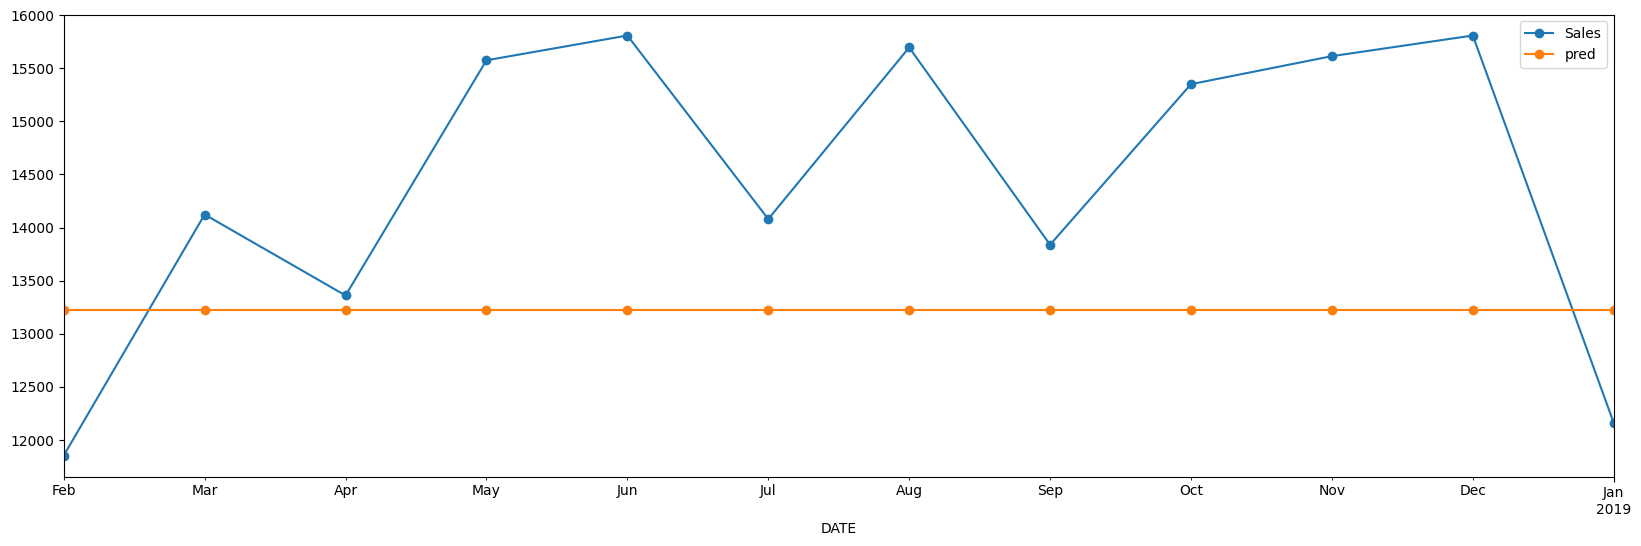

In [ ]:
model = sm.tsa.SimpleExpSmoothing(train_x.Sales).fit(smoothing_level=1/(2*12))
test_x['pred'] = model.forecast(steps = 12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### Drawbacks
This simple exponential smoothing model is slightly smarter than the moving average model thanks to its smarter weighting of the historical demand observation. But it has many limitations:

- It does not project trends.
- It does not recognize any seasonal pattern.

# Double Exponential smoothing (Holt's method)

Double Exponential Smoothing is an extension to Exponential Smoothing that explicitly adds support for trends in the univariate time series.

Since we want the trend of entire time series, in order to incorporate them, we will have to provide weights to the trend value also.

Naturally, this will also form a exponentially decaying series.

Hence this is called **Double Exponential smoothing (aka Holt's method)**

In addition to the alpha parameter for controlling smoothing factor for the level, an additional smoothing factor is added to control the decay of the influence of the change in trend called beta (b).

As with alpha, beta can be between 0 and 1, inclusive. Higher values place more weight on recent observations, allowing the trend component to react more quickly to changes in the trend.



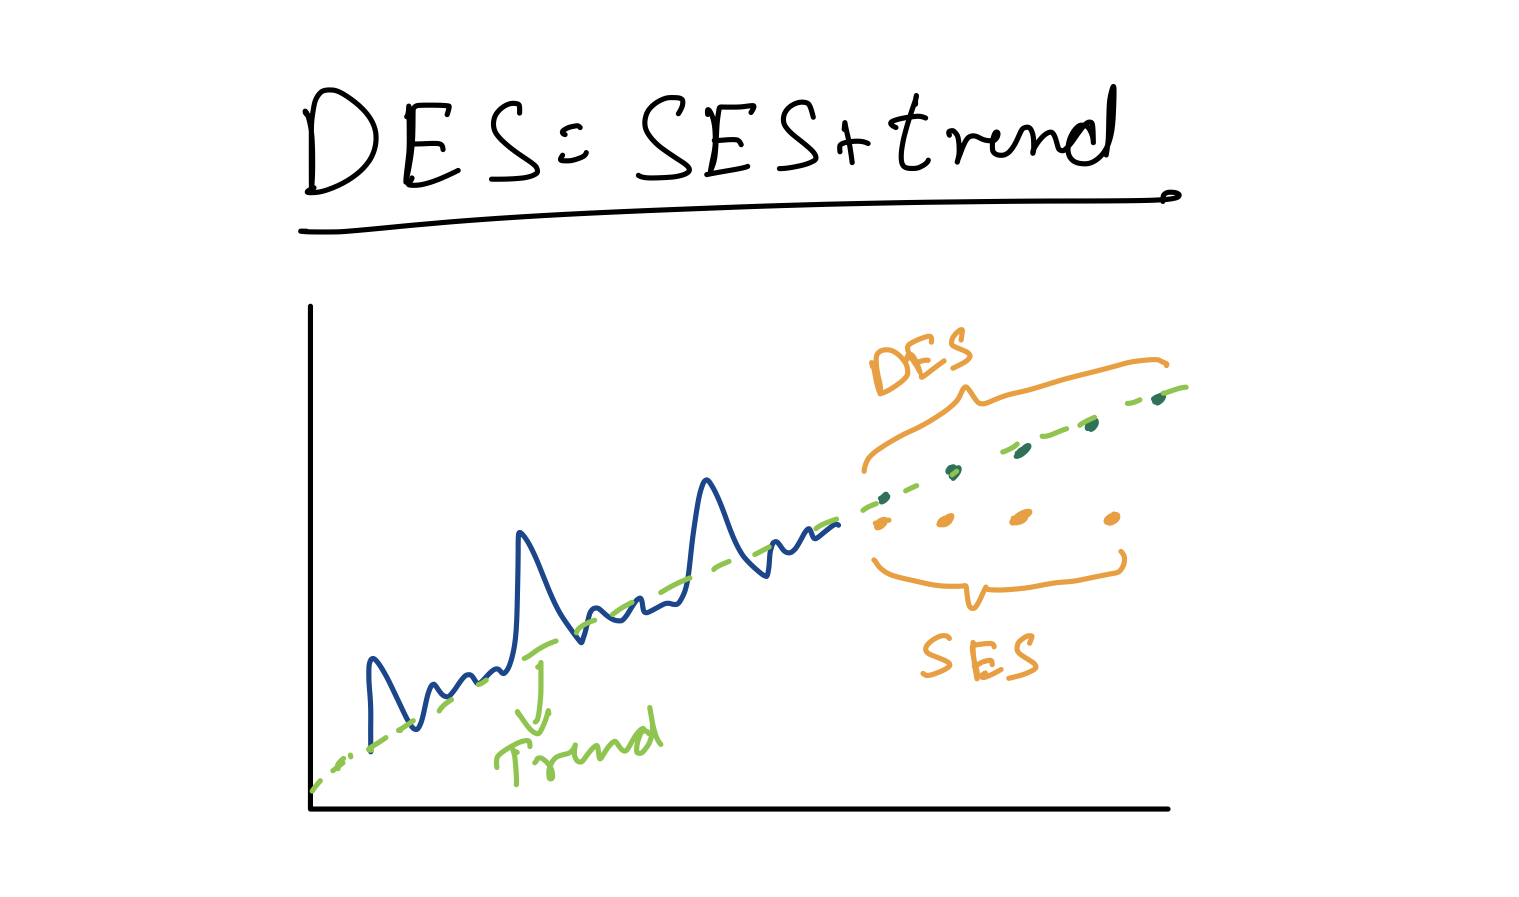

- Should be used on the time series that have no seasonality and have single variable (feature)

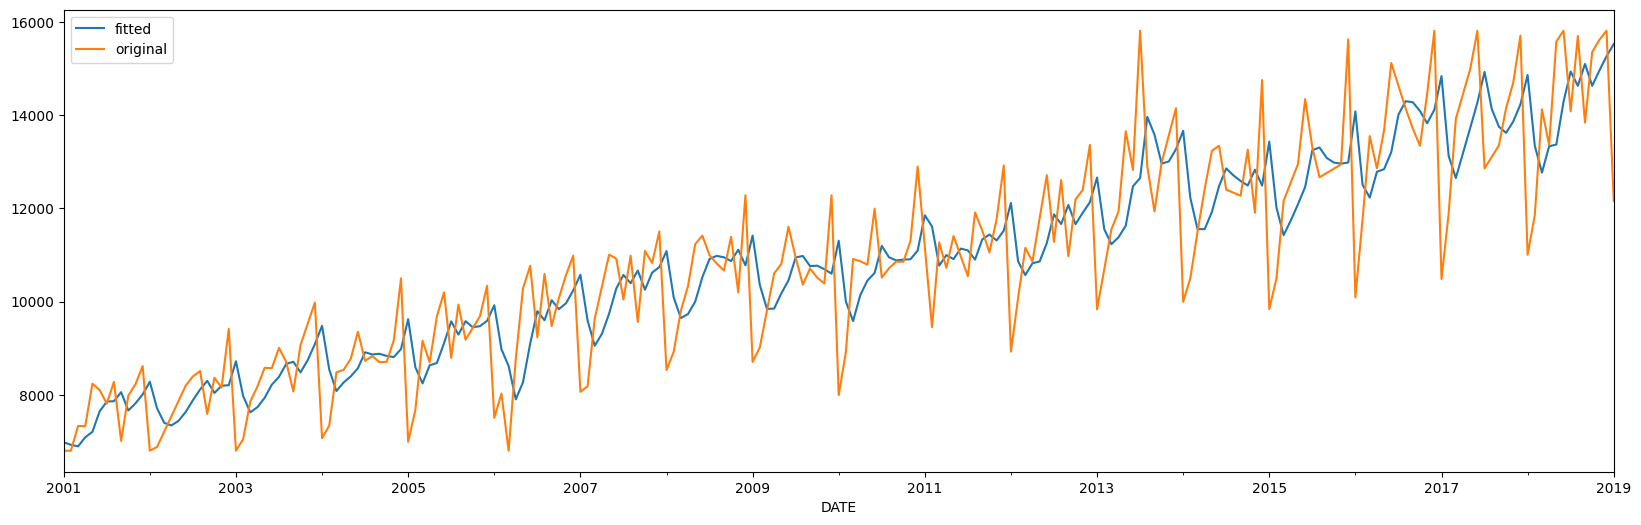

In [ ]:
model = sm.tsa.ExponentialSmoothing(myntra_sales.Sales, trend='add').fit(smoothing_level=0.4)
model.fittedvalues.plot(label='fitted')
myntra_sales.Sales.plot(label='original')
plt.legend()

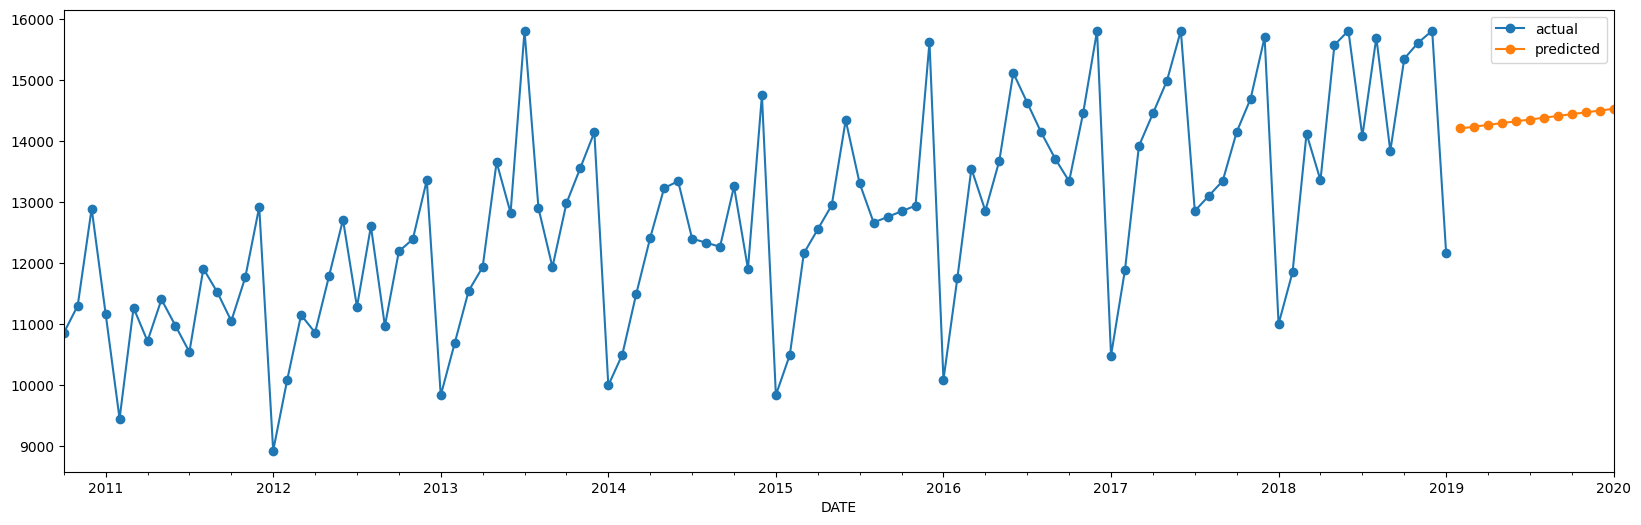

In [ ]:
pred = model.forecast(steps = 12)
myntra_sales.Sales.tail(100).plot(style='-o', label='actual')
pred.plot(style='-o', label='predicted')
plt.legend()

From the graph you can see that, the trend of the series is also obtained along with the level of values.

<br>



While we're at it, let's check the performance of Holt's method model also, by using train and test sets.

MAE : 1163.781
RMSE : 1352.497
MAPE: 0.083


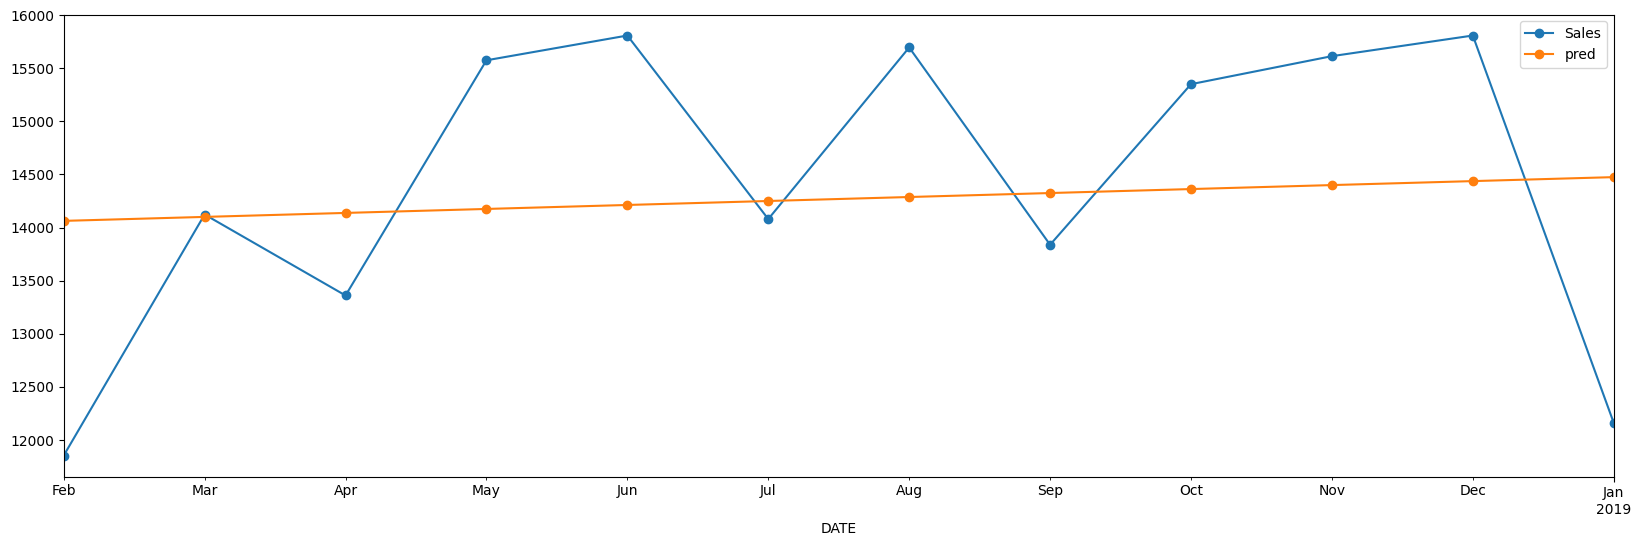

In [ ]:
model = sm.tsa.ExponentialSmoothing(train_x.Sales, trend='add').fit(smoothing_level=1/(2*12))
test_x['pred'] = model.forecast(steps = 12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

# Triple Exponential smoothing (aka Holt-Winters Method)

Triple Exponential Smoothing is an extension of Exponential Smoothing that explicitly adds support for seasonality to the univariate time series.

This method is sometimes called Holt-Winters Exponential Smoothing, named for two contributors to the method: Charles Holt and Peter Winters.

In addition to the alpha and beta smoothing factors, a new parameter is added called gamma (g) that controls the influence on the seasonal component.

- This method adds in the gamma (γ) parameter to account for the seasonal component. For this method, you must specify the period for the seasonal cycle. For example, these lengths include the following: weekly (7), monthly (12), or quarterly (4).

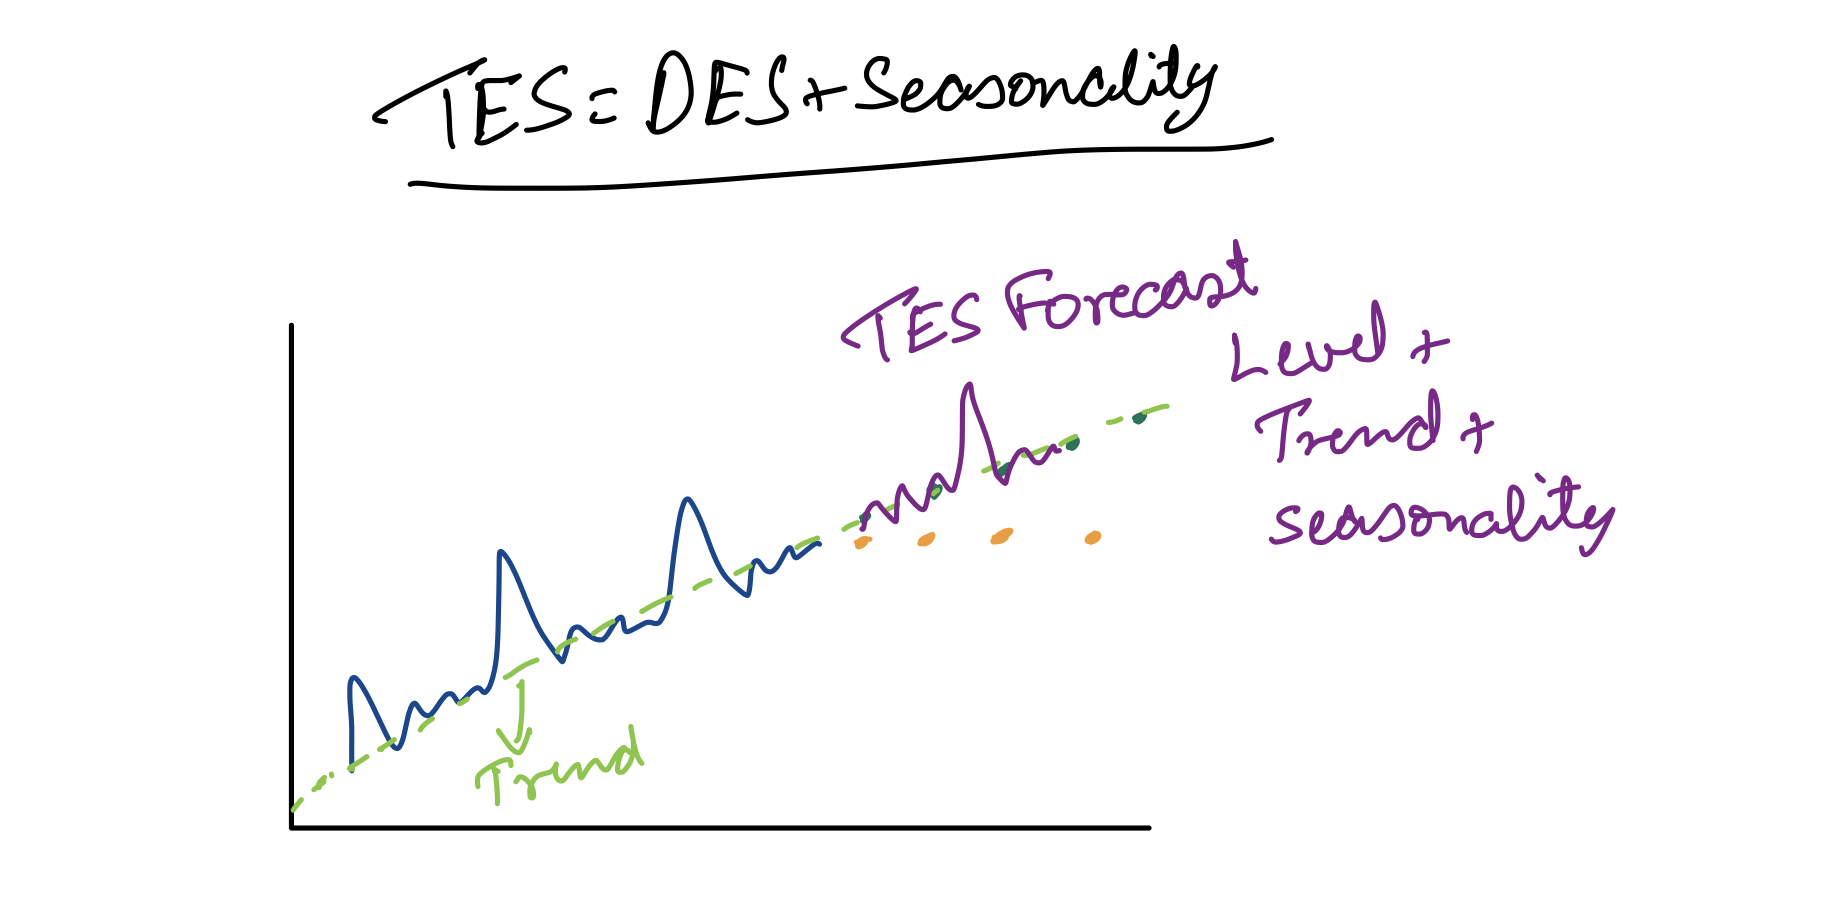

This method;

- Can handle level, trend and seasonality
- In addition to SES, the trend and seasonality is also taken into account
- Is the most improved smoothing method
- Forecasts dynamically consider level, trend and seasonality
- Should be used with the time series that have trend and/or seasonality and single variable (feature)

<Axes: xlabel='DATE'>

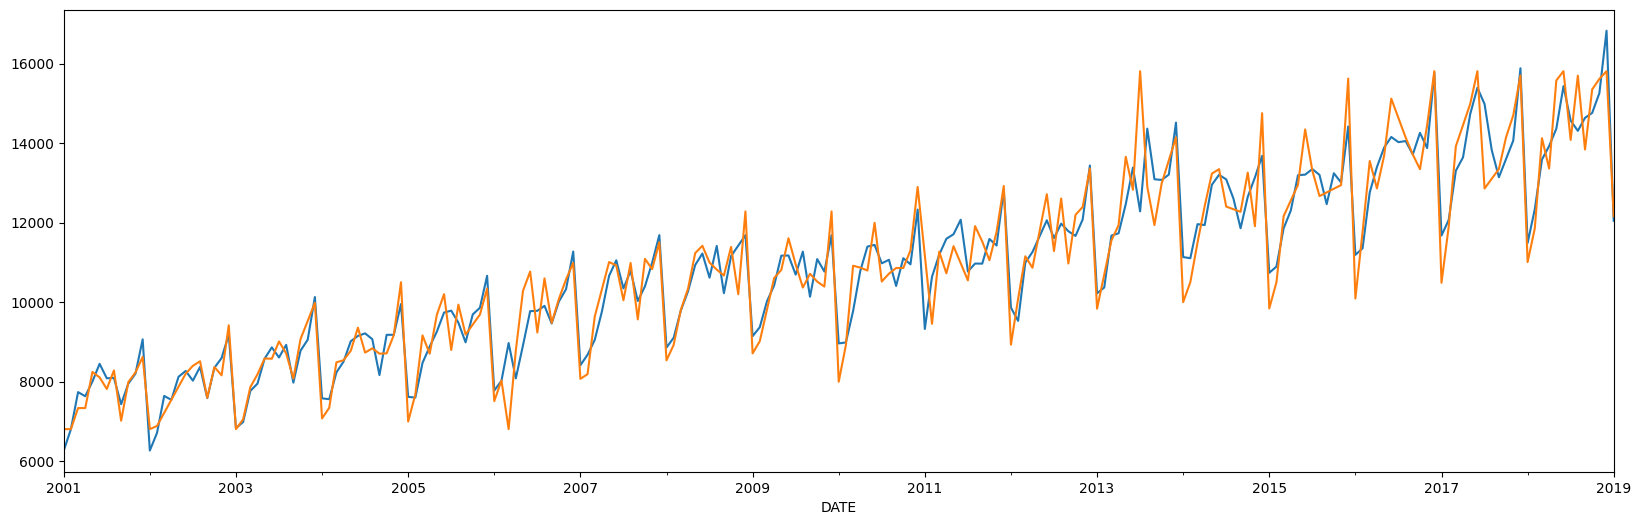

In [ ]:
model = sm.tsa.ExponentialSmoothing(myntra_sales.Sales, trend='add', seasonal='add').fit(smoothing_level=0.4)
model.fittedvalues.plot()
myntra_sales.Sales.plot()

As you can see, this captures more information than Double Exponential smoothing.

This was expected as it has more degrees of freedom to capture more data.

<Axes: xlabel='DATE'>

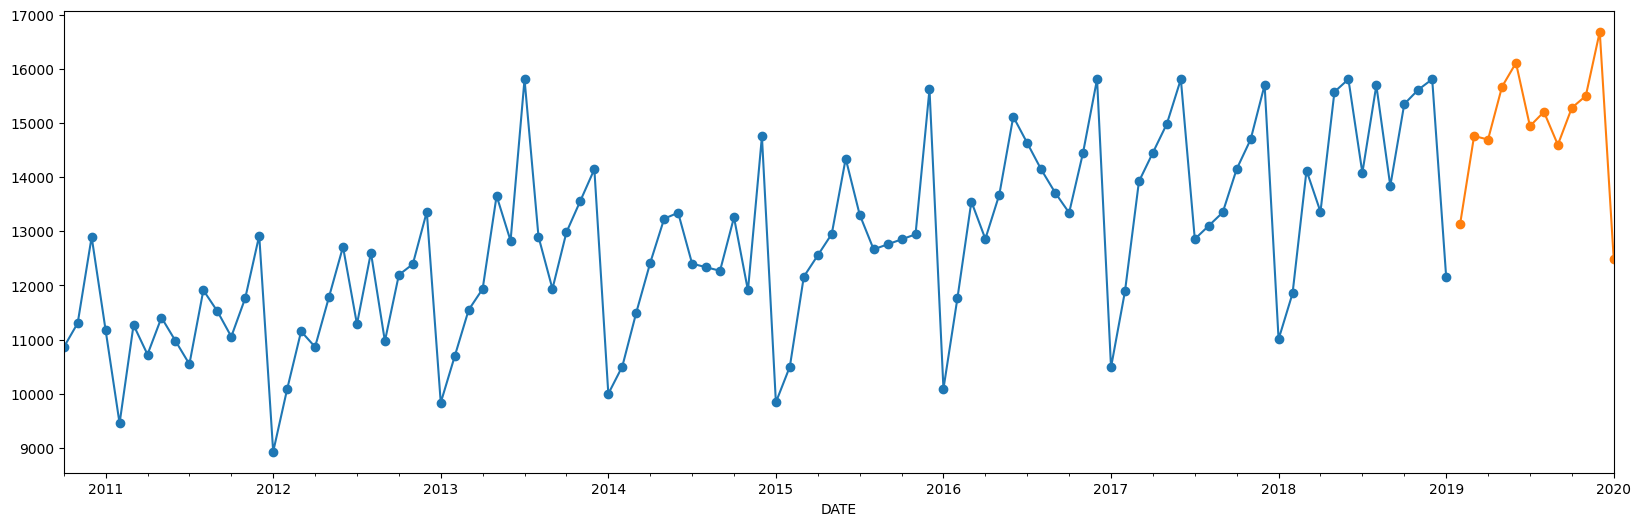

In [ ]:
pred = model.forecast(steps = 12)
myntra_sales.Sales.tail(100).plot(style='-o')
pred.plot(style='-o')

From the plot we can see that our forecasts now look promising upon incorporating the trend and seasonality components.

<br>



While we're at it, let's check the performance of Holt-Winter's method model also, by using train and test sets.

MAE : 582.172
RMSE : 667.354
MAPE: 0.04


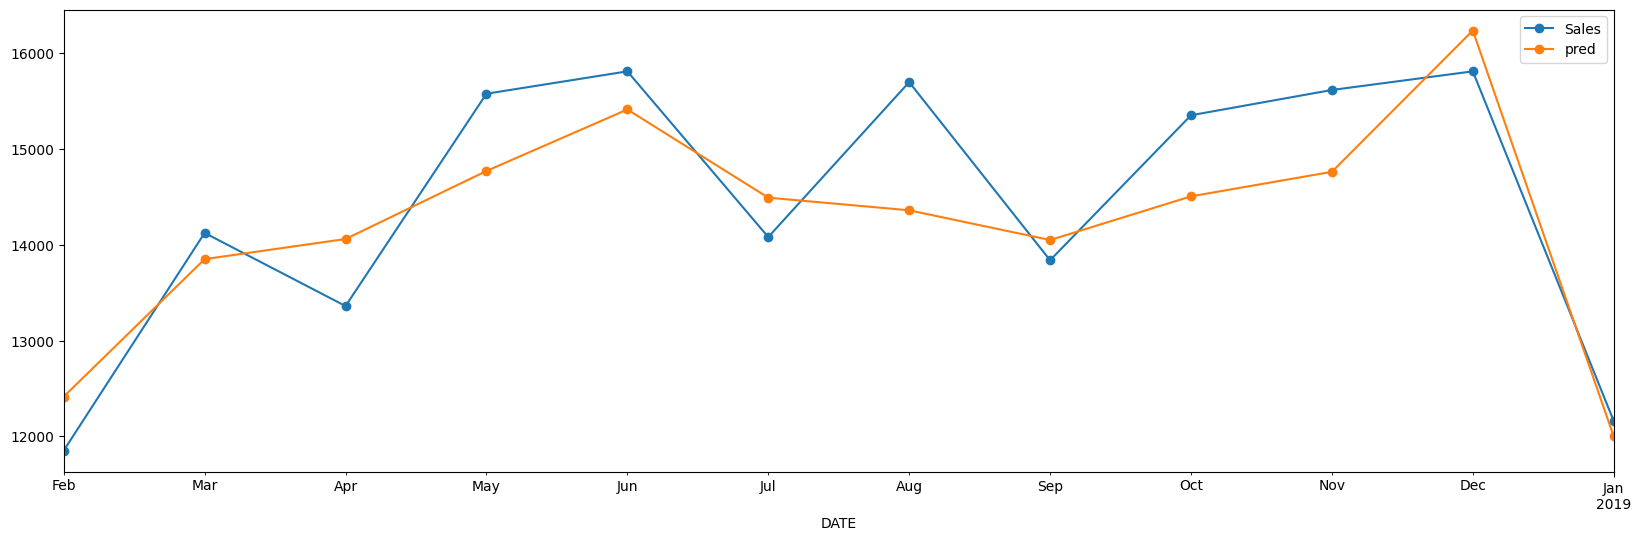

In [ ]:
model = sm.tsa.ExponentialSmoothing(train_x.Sales, trend='add', seasonal='add').fit(smoothing_level=1/(2*12))
test_x['pred'] = model.forecast(steps=12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

In this plot we can clearly see that this model is having a better performance.

To back this, we can see that even MAPE error is only 4% now.

Also, the MAE and RMSE values have gone down a lot, from where we started.

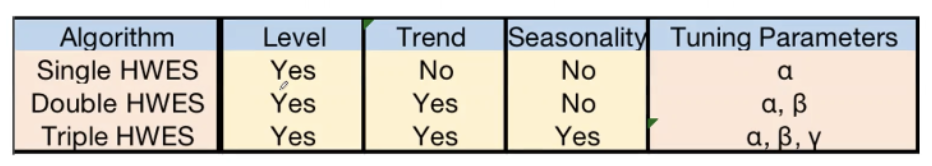

# Stationarity

A stationary time series is one whose properties do not depend on the time at which the series is observed. Thus, time series with trends, or with seasonality, are not stationary — the trend and seasonality will affect the value of the time series at different times. On the other hand, a white noise series is stationary — it does not matter when you observe it, it should look much the same at any point in time.

- So far, we've been dealing with non-stationary time series. But in order to use certain forecasting methods (that we will see shortly), we need to the series to be stationary.


Being stationary means that, parameters (like mean, variance, amplitude, frequency) of the models should not be dependent on time.

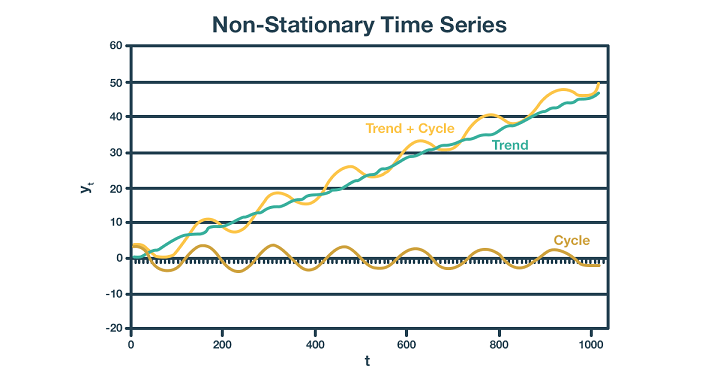




<br>

> **Q. Which of the following time series is stationary?**

![picture](https://drive.google.com/uc?export=view&id=1pN4X8e7xNcQvnpgCmGgl7gQZURcD3kRy)

- `a, c, e, f, :` Not stationary
 - either have a trend, or
 - mean changing with time.
- `d, h:` Not stationary
 - Seasonality
- `i:` Not stationary
 - Has a trend
 - Variance is also not stable
 - Season
- `b:`
 Stationary
 - There is 1 outlier
 - Can't say anything about mean; seems to be just noise.
- `g:` Stationary
  - Predicting this is dicey, so we assume it to be stationary, and try building model, and seeing if it performs.
  - Looks like a cyclic time series. But these are not at regular intervals.
  - So, even though there  is some seasonality, it can't be predicted.

Categorizing a time series by just looking at it can be a little subjective.

For example, somebody may argue that `plot b` is non-stationary, as it looks like there may be some seasonality there.

In general, a stationary time series will have no predictable patterns in the long-term. Time plots will show the series to be roughly horizontal (although some cyclic behaviour is possible), with constant variance.

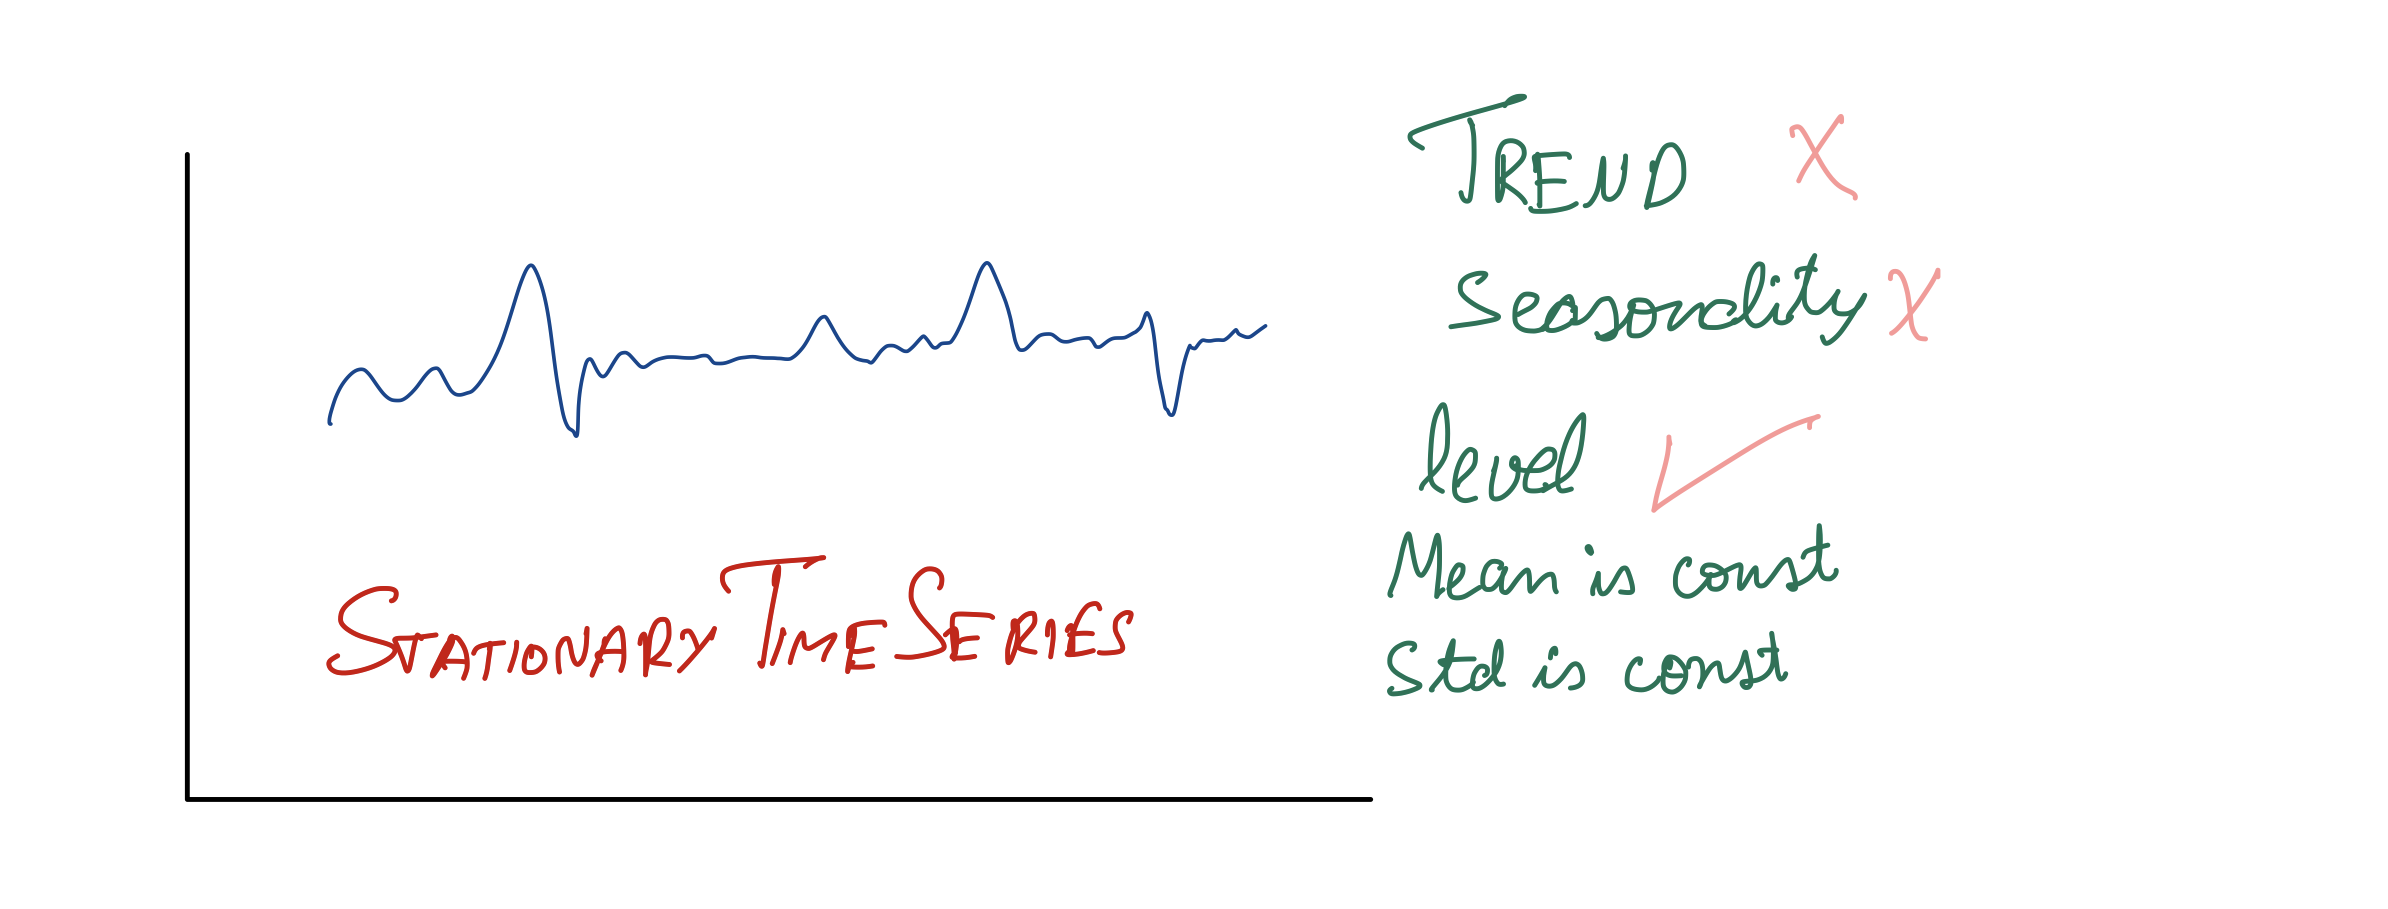

### Dickey-Fuller Test


There is a **statistical** method called **Dickey-Fuller test**, designed for testing for stationarity. It is one of the most commonly used statistical test when it comes to analyzing the stationary of a series.


It fits an auto regressive model, checks if it worked or not. If it did, then that means it was a stationary time series.

There is a complicated mechanism to it. We don't need to know how it works. Just need to be aware of this test, as it can be handy.

<br>


We can find this as a built in function under **statmodels** library as `sm.tsa.stattools.adfuller()`.

<br>

> **Q. How do we interpret the result of Dickey-Fuller test?**

This test returns the **pvalue**.

In order for a time series to be stationary, the **pvalue** should be less than 0.05

Let's do the test for our timeseries

In [ ]:
sm.tsa.stattools.adfuller(myntra_sales.Sales)[1]

0.9789233920172065

The pvalue of the timeseries is very high, 0.98 approx.

So we can conclude that our time series is **not stationary**.

This makes sense because our time series has both, trend and seasonality.

Let's define a simple function to know if the plot is stationary or not.

In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')


In [ ]:
adf_test(myntra_sales.Sales)

Sequence is not stationary


### Making series stationary

As per basic intuition, if we remove trend and seasonality, from our time series, it should become stationary.

If it's still not stationary, then maybe there's still some seasonality or trend component left in the series.

Ideally, trend gets removed in one step. However seasonality can take multiple steps to be removed.


---

### De-trending the series

A trend is often easily visualized as a line through the observations.
Perhaps the simplest method to detrend a time series is by differencing.

Specifically, a new series is constructed where the value at the current time step is calculated as the difference between the original observation and the observation at the previous time step.


A detrend involves removing the effects of trend from a data set to show only the differences in values from the trend; it allows cyclical and other patterns to be identified.

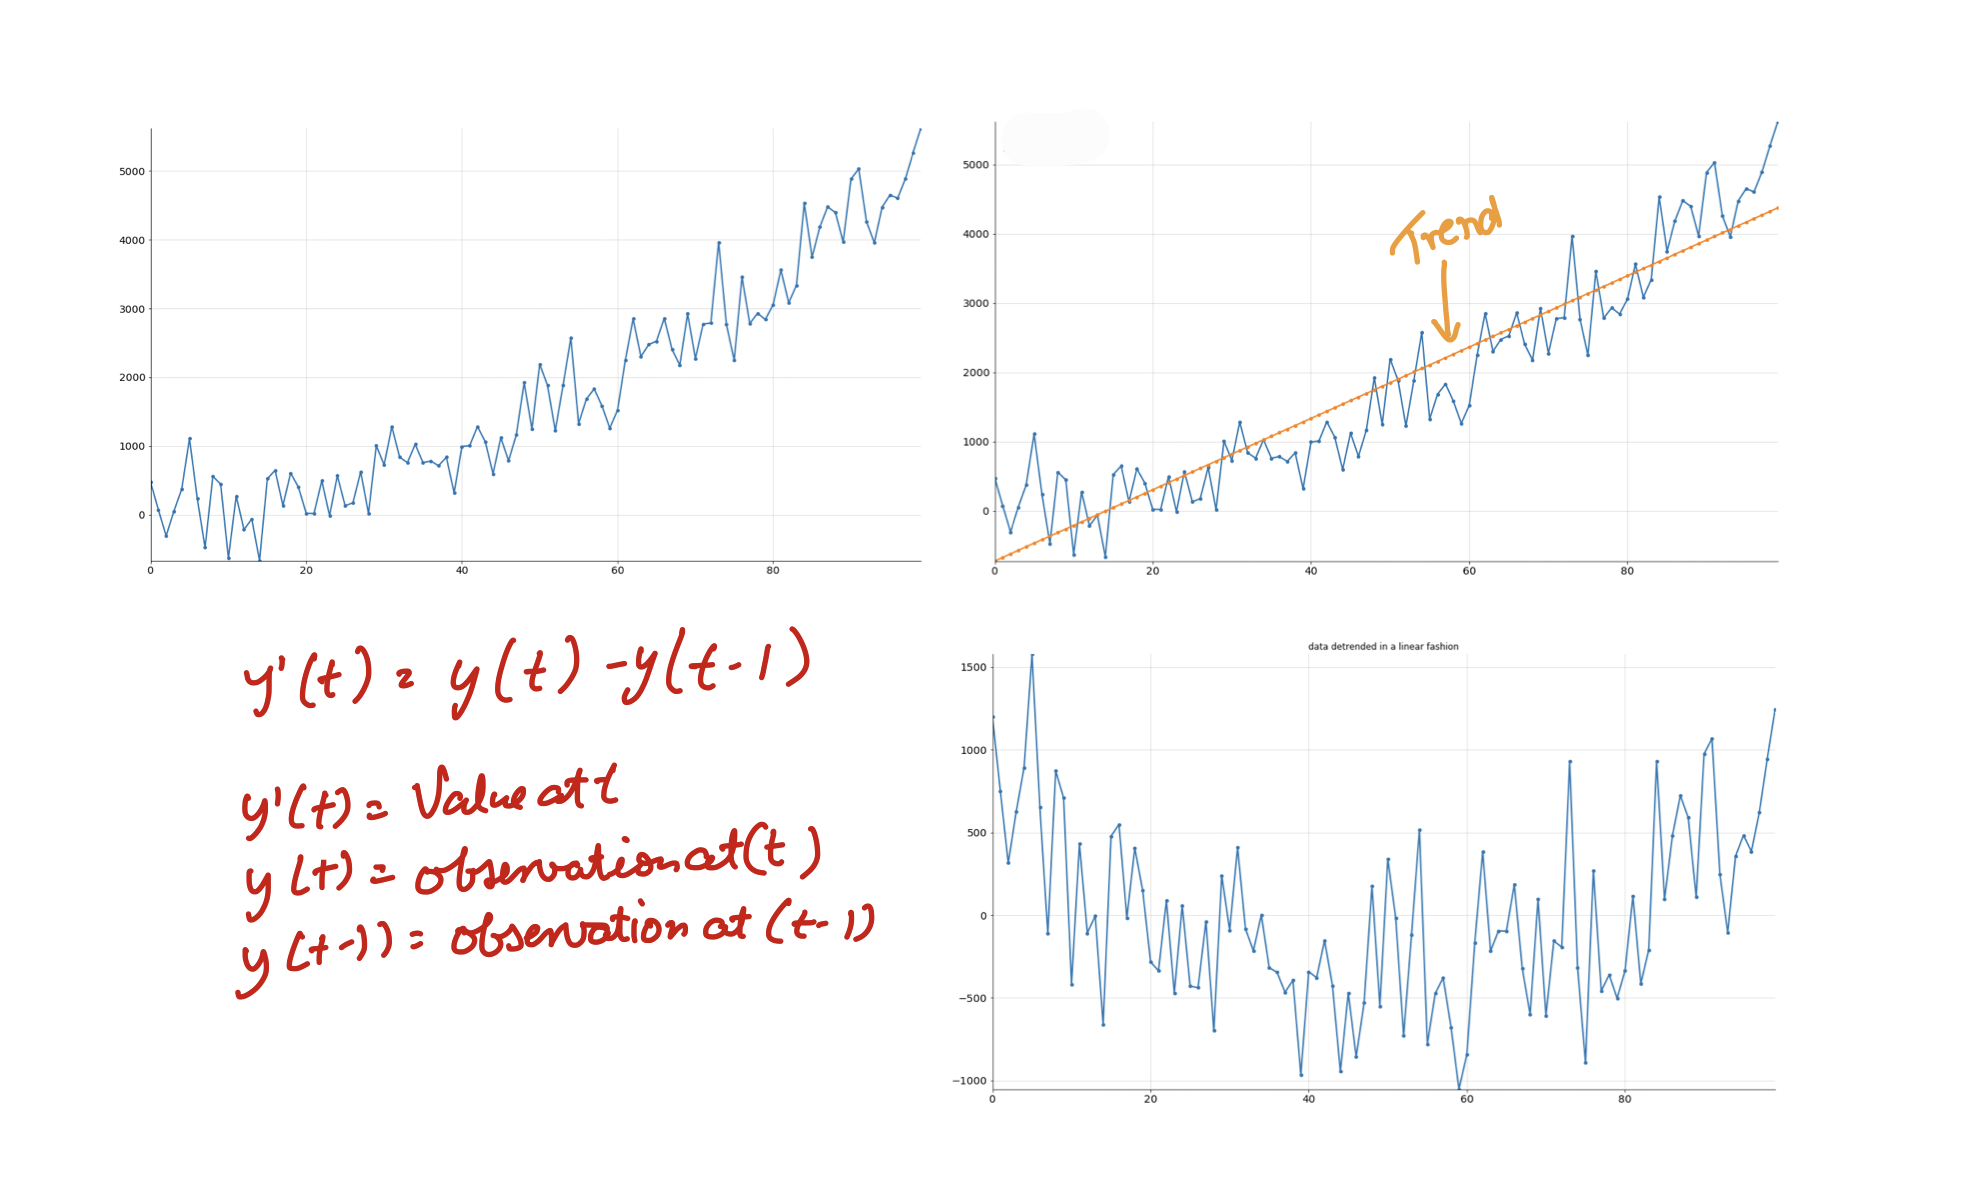

If the time series has a non-linear trend, then we'll have to differentiate it multiple times, in order to finally achieve a stationary series.

Note:

If the trend is an exponential function, then we'll not be able to convert it into stationary.
This is a very rare cases.
Some exponential functions can be approximated by polynomial. In that case, we differentiate this polynomial to obtain a stationary time series.

<Axes: xlabel='DATE'>

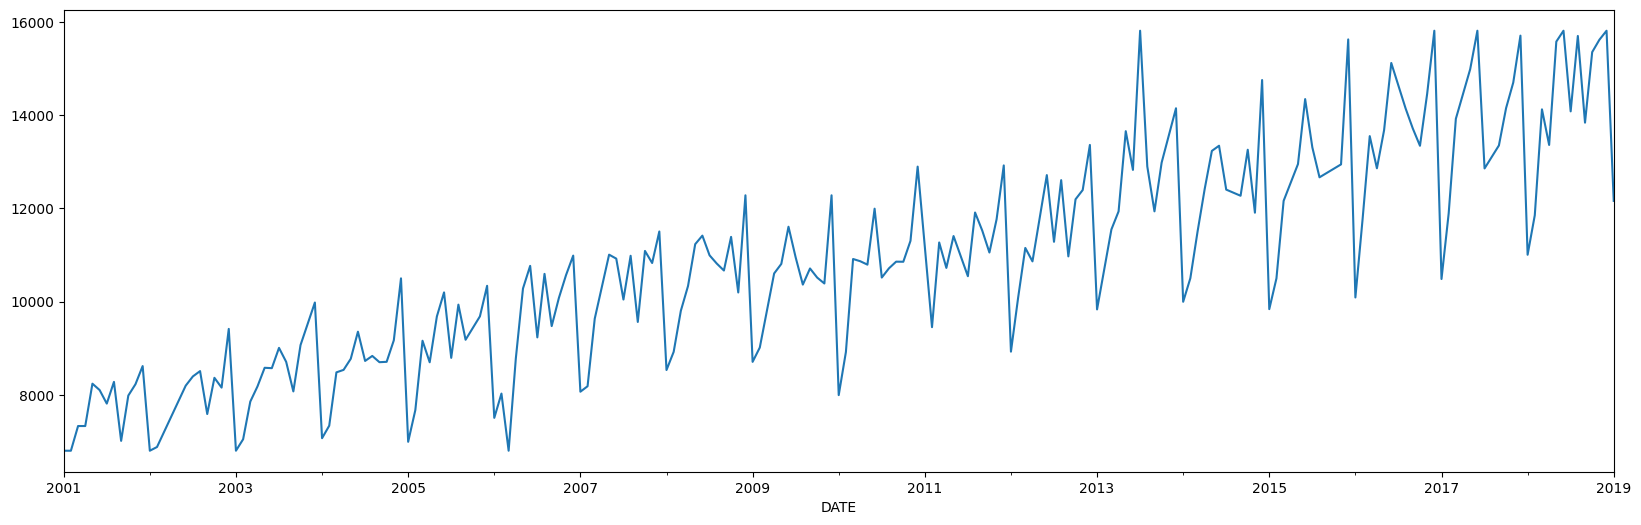

In [ ]:
myntra_sales.Sales.plot()


We use the `diff()` method of **pandas**.

This method calculates the difference of a Dataframe element compared with another element in the Dataframe (default is element in previous row, as the default value is 1).

<Axes: xlabel='DATE'>

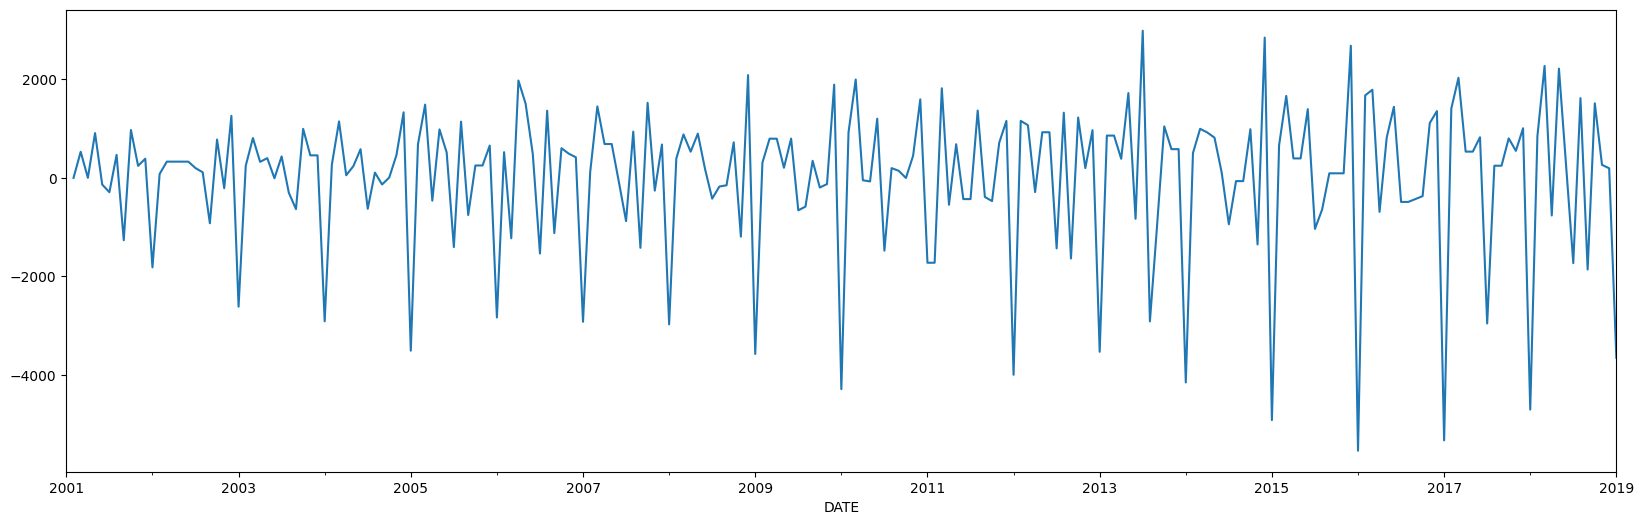

In [ ]:
detrend = myntra_sales.Sales.diff()
detrend.plot()

As you can see, here the series has been detrended.

Let's perform the Dicker-Fuller test to cross check.

In [ ]:
adf_test(detrend.dropna())

Sequence is stationary


In [ ]:
sm.tsa.stattools.adfuller(detrend.dropna())[1]

1.1781888996320098e-16

### De-seasonalising

The model of seasonality can be removed from the time series. This process is called Seasonal Adjustment, or Deseasonalizing.

Here also we can use differencing, but instead of subtracting from the last point, we need to take a difference from the last mth point, where m is the period of seasonality of series.

###**$Δy = y_t - y_{t-m}$**

This is called m-differencing.

If there is a seasonal component at the level of one week, then we can remove it on an observation today by subtracting the value from last week.

In our case, since data is monthly, our m=12

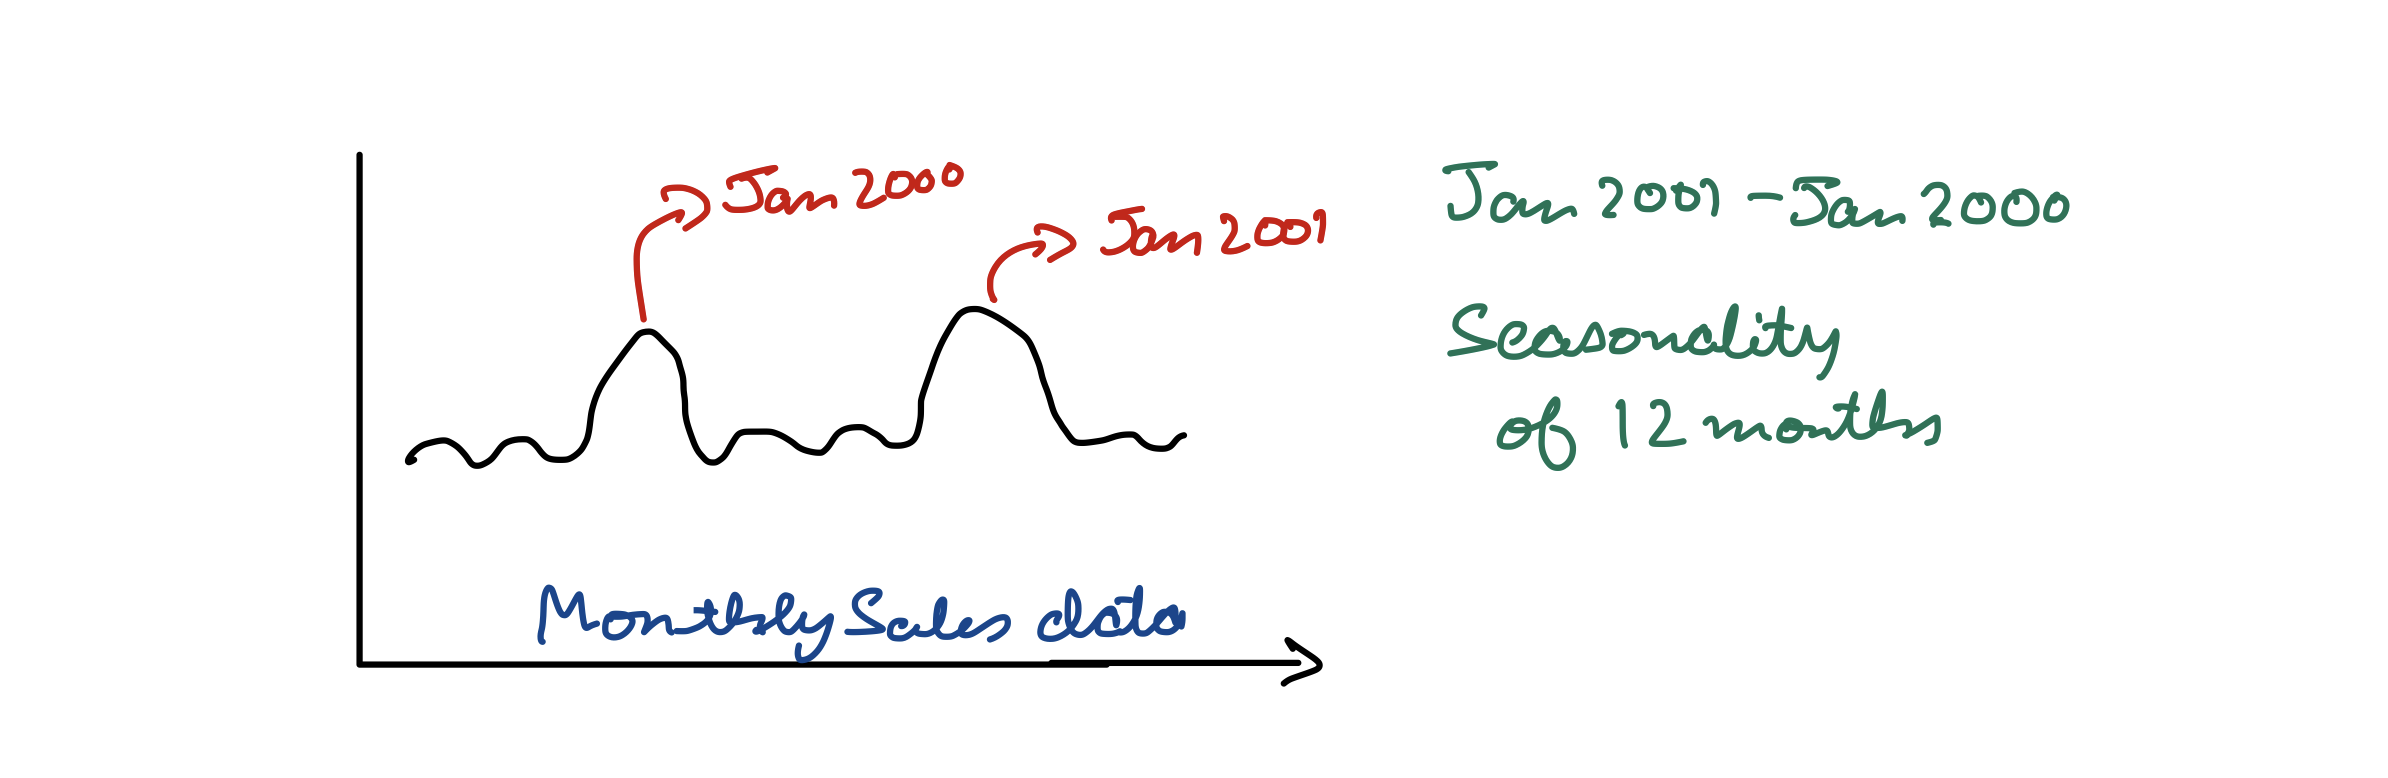

<Axes: xlabel='DATE'>

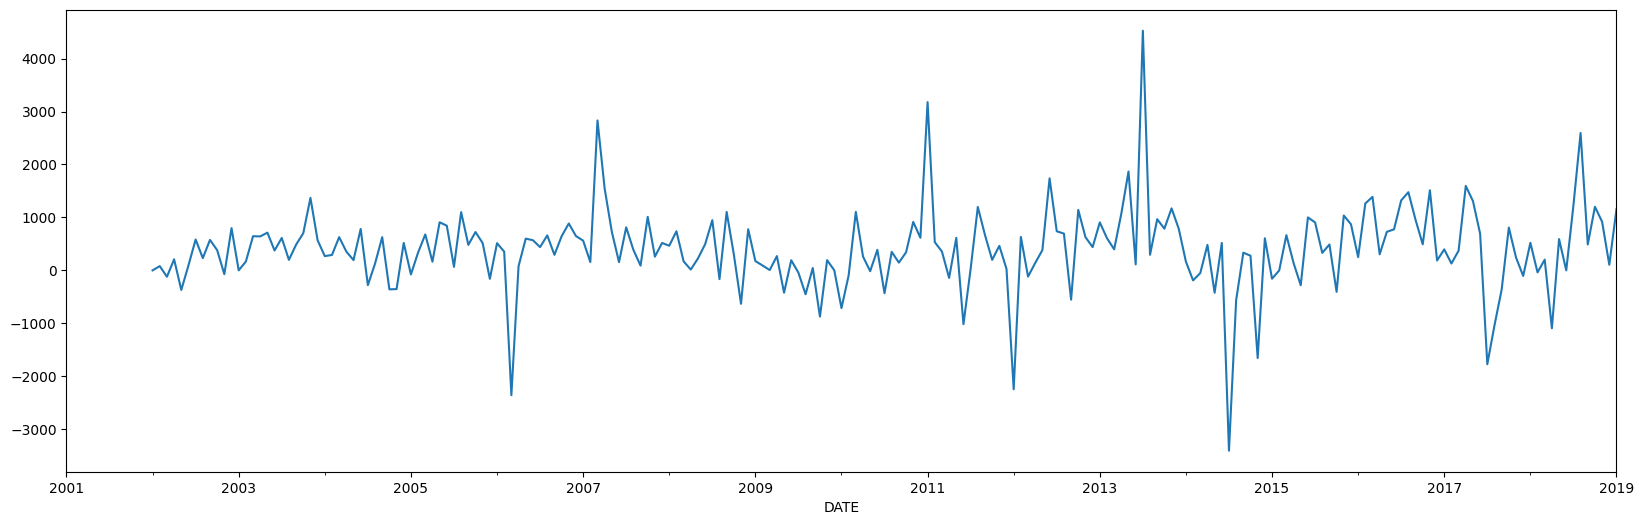

In [ ]:
deseas = myntra_sales.Sales.diff(12)
deseas.plot()

In [ ]:
sm.tsa.stattools.adfuller(myntra_sales.Sales.diff(1).dropna())[1]

1.1781888996320098e-16

Here, as you can see we can still see very small trace of trend still.

Let's try detrending AND deseasonalising at once.

<Axes: xlabel='DATE'>

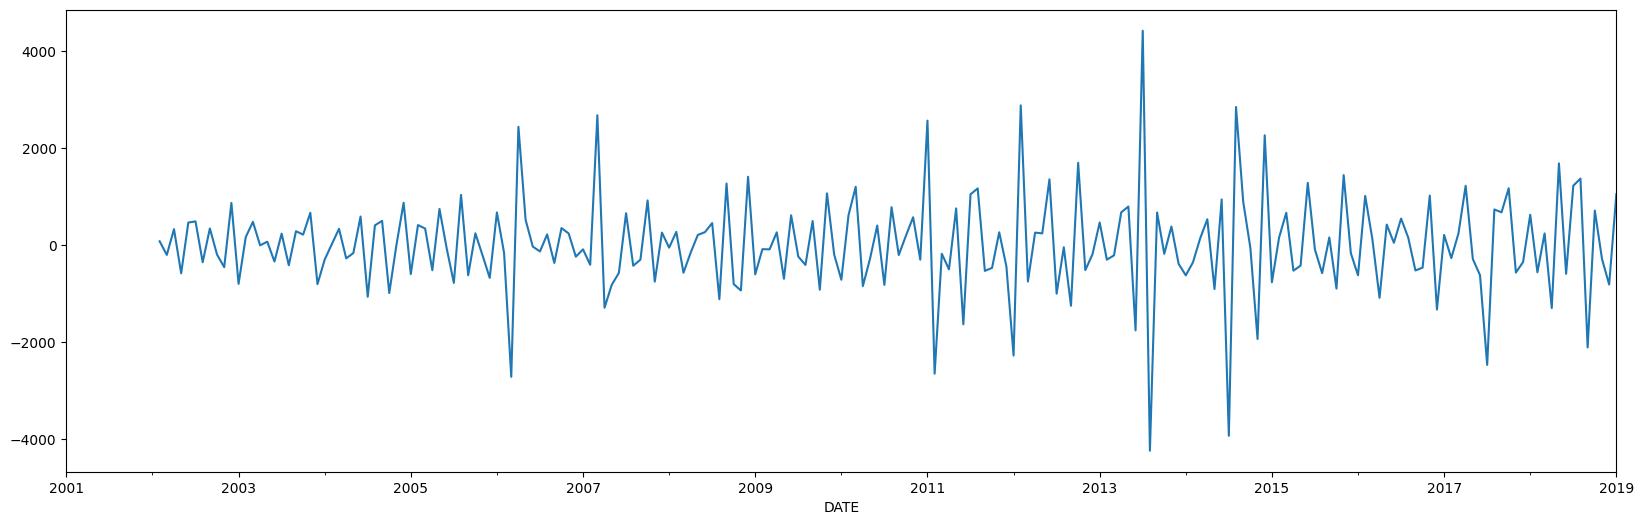

In [ ]:
stationary = myntra_sales.Sales.diff(1).diff(12)
stationary.plot()

In [ ]:
sm.tsa.stattools.adfuller(myntra_sales.Sales.diff(1).diff(12).dropna())[1]

1.4566207430682365e-06

As you can see, we've obtained a stationary time series.

**We have removed both trend and seasonality from the time series**


<br>

> **Here, we could visually see in the plot that value of m seems to be 12, but in other cases, it might not be obvious.**
- So we need to find the optimal value of m.
